In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from openpyxl import load_workbook

In [2]:
wb = load_workbook("have_fun.xlsx", data_only=True)


def decode_title(title: str) -> str:
    if not isinstance(title, str):
        return title

    try:
        return title.encode("latin1").decode("cp1251")
    except (UnicodeDecodeError, UnicodeEncodeError):
        return title


analysis_table = []
for sheet_name in wb.sheetnames:
    sheet = wb[sheet_name]
    analysis_table.append({
        "title": sheet.title,
        "fixed_title": decode_title(sheet.title),
        "state": sheet.sheet_state,
        "max_row": sheet.max_row,
        "max_column": sheet.max_column
    })

print(analysis_table)

[{'title': 'Ëèñò1', 'fixed_title': 'Лист1', 'state': 'visible', 'max_row': 125125, 'max_column': 10}, {'title': 'Лист1', 'fixed_title': 'Лист1', 'state': 'visible', 'max_row': 1, 'max_column': 1}, {'title': 'ÌÀÈ', 'fixed_title': 'МАИ', 'state': 'visible', 'max_row': 1, 'max_column': 1}, {'title': 'ýòî', 'fixed_title': 'это', 'state': 'visible', 'max_row': 1, 'max_column': 1}, {'title': 'ÿ', 'fixed_title': 'я', 'state': 'visible', 'max_row': 1, 'max_column': 1}, {'title': '!', 'fixed_title': '!', 'state': 'visible', 'max_row': 1, 'max_column': 1}, {'title': 'Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû', 'fixed_title': 'Лист2_строковые_NaN_выбросы', 'state': 'hidden', 'max_row': 125170, 'max_column': 25}, {'title': 'Ëèñò3_ñìåøàííûå_òèïû', 'fixed_title': 'Лист3_смешанные_типы', 'state': 'hidden', 'max_row': 122737, 'max_column': 10}]


4 названия листов образуют "МАИ это я!". 5 листов пустые + 3 листа заполненные, как и говорилось в ТЗ. Причем 2 листа с данными скрыты.

In [3]:
for sheet_name in wb.sheetnames:
    sheet = wb[sheet_name]

    if sheet.max_row > 1 and sheet.max_column > 1:
        print(f"Original title: {sheet.title}")
        print(f"Decoded title: {decode_title(sheet.title)}")
        print(f"Size: {sheet.max_row} x {sheet.max_column}")

        rows = []
        for row in sheet.iter_rows(min_row=1, max_row=5, values_only=True):
            decoded_row = [decode_title(i) for i in row]
            rows.append(decoded_row)

        df = pd.DataFrame(rows)
        display(df)


Original title: Ëèñò1
Decoded title: Лист1
Size: 125125 x 10


,0,1,2,3,4,5,6,7,8,9
0,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,ds,city
1,3.8,82.0,0.0,0.0,0.0,3.0,19.1,1010.0,2020-01-31 02:00:00,Геленджик
2,-3.0,70.0,0.0,0.0,0.0,3.0,24.0,981.900024,2025-02-28 09:00:00,Благовещенск
3,-1.3,86.0,0.0,0.0,0.0,2.0,8.8,1021.200012,2022-01-03 02:00:00,Геленджик
4,19.299999,49.0,0.0,0.0,0.0,0.0,22.799999,1016.200012,2020-09-17 06:00:00,Геленджик


Original title: Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû
Decoded title: Лист2_строковые_NaN_выбросы
Size: 125170 x 25


,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,ds,city,...,None,None,None,None,None,None,None,None,None,None
1,-6.5,92.0,0.0,0.0,0.0,3.0,10.8,1000.5,2019-01-01 00:00:00,Москва,...,None,None,None,None,None,None,None,None,None,None
2,-6.8,92.0,0.0,0.0,0.0,3.0,10.5,1000.299988,2019-01-01 01:00:00,Москва,...,None,None,None,None,None,None,None,None,None,None
3,-6.8,92.0,0.0,0.0,0.0,3.0,10.8,1000.0,2019-01-01 02:00:00,Москва,...,None,None,None,None,None,None,None,None,None,None
4,-5.8,93.0,0.0,0.0,0.0,3.0,12.2,999.299988,2019-01-01 03:00:00,Москва,...,None,None,None,None,None,None,None,None,None,None


Original title: Ëèñò3_ñìåøàííûå_òèïû
Decoded title: Лист3_смешанные_типы
Size: 122737 x 10


,0,1,2,3,4,5,6,7,8,9
0,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,ds,city
1,-1.8,85.0,0.0,0.0,0.0,3.0,23.5,1015.200012,2019-01-01 00:00:00,Санкт-Петербург
2,-1.9,83.0,0.0,0.0,0.0,3.0,26.0,1013.200012,2019-01-01 01:00:00,Санкт-Петербург
3,-2.0,85.0,0.0,0.0,0.0,3.0,26.200001,1011.700012,2019-01-01 02:00:00,Санкт-Петербург
4,-2.3,86.0,0.0,0.0,0.0,3.0,26.9,1009.900024,2019-01-01 03:00:00,Санкт-Петербург


Мы видим, что 1 и 3 таблицы идентичны по количеству и названий колонк, а вот 2 таблица отличается тем, что в ней на 15 столбцов больше. Вряд ли openpyxl глупа и просто так считает пустые колонки. Нужно будет проверить, что есть в этой области

In [4]:
sheet_name = "Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû"
sheet = wb[sheet_name]

for col_ind in range(11, sheet.max_column + 1):
    non_empty = 0
    first = last = None

    for row_ind in range(1, sheet.max_row):
        cell = sheet.cell(row=row_ind, column=col_ind).value

        if cell is not None:
            non_empty += 1
            if first is None:
                first = row_ind
            last = row_ind

    print(f"Col {col_ind}: непустых значений - {non_empty}, first - {first}, last - {last}")

Col 11: непустых значений - 0, first - None, last - None
Col 12: непустых значений - 1, first - 84029, last - 84029
Col 13: непустых значений - 1, first - 84029, last - 84029
Col 14: непустых значений - 1, first - 84029, last - 84029
Col 15: непустых значений - 41, first - 84029, last - 84069
Col 16: непустых значений - 148, first - 15, last - 84069
Col 17: непустых значений - 149, first - 15, last - 84069
Col 18: непустых значений - 148, first - 15, last - 84069
Col 19: непустых значений - 149, first - 15, last - 84069
Col 20: непустых значений - 149, first - 15, last - 84069
Col 21: непустых значений - 149, first - 15, last - 84069
Col 22: непустых значений - 108, first - 15, last - 122
Col 23: непустых значений - 108, first - 15, last - 122
Col 24: непустых значений - 108, first - 15, last - 122
Col 25: непустых значений - 107, first - 15, last - 122


Дальше я хочу посмотреть какие вообще могут быть данные в этих диапазонах

In [5]:
def show_range(sheet, min_row, max_row, min_col, max_col):
    rows = []

    for row in sheet.iter_rows(
        min_row=min_row,
        max_row=max_row,
        min_col=min_col,
        max_col=max_col,
        values_only=True
    ):
        decoded_row = [decode_title(i) for i in row]
        rows.append(decoded_row)

    return pd.DataFrame(rows)


display(show_range(sheet, 84029, 84029, 12, 14))
display(show_range(sheet, 84029, 84039, 15, 15))
display(show_range(sheet, 15, 25, 16, 25))

,0,1,2
0,temperature_2m,relative_humidity_2m,precipitation


,0
0,rain
1,0.0
2,0.0
3,0.0
4,0.0
5,0.2
6,0.7
7,1.5
8,1.8
9,0.5


,0,1,2,3,4,5,6,7,8,9
0,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,ds,city
1,-0.4,66.0,0.0,0.0,0.0,1.0,9.4,1025.099976,2022-11-11 07:00:00,Находка
2,0.1,67.0,0.0,0.0,0.0,2.0,7.1,1025.099976,2022-11-11 08:00:00,Находка
3,2.2,64.0,0.0,0.0,0.0,3.0,7.3,1025.599976,2022-11-11 09:00:00,Находка
4,3.9,63.0,0.0,0.0,0.0,3.0,6.6,1026.199951,2022-11-11 10:00:00,Находка
5,5.3,61.0,0.0,0.0,0.0,3.0,2.0,1026.0,2022-11-11 11:00:00,Находка
6,6.8,62.0,0.0,0.0,0.0,3.0,3.1,1025.699951,2022-11-11 12:00:00,Находка
7,8.2,56.0,0.0,0.0,0.0,3.0,6.4,1024.699951,2022-11-11 13:00:00,Находка
8,8.9,53.0,0.0,0.0,0.0,3.0,6.1,1023.799988,2022-11-11 14:00:00,Находка
9,8.4,58.0,0.0,0.0,0.0,3.0,7.6,1023.299988,2022-11-11 15:00:00,Находка


In [6]:
def missing_values(val):
    missing_markers = {
        "",
        "?",
        "нет данных",
        "NA",
        "NAN",
        "NaN",
        "nan",
        "n/a",
        "null",
        "NULL",
        "---",
    }

    if val is None or pd.isna(val) or (isinstance(val, str) and decode_title(val).strip() in missing_markers):
        return True
    return False


block = show_range(sheet, 15, 122, 16, 25)
block_header = block.iloc[0].tolist()
block_data = block.iloc[1:].copy()
block_data.columns = block_header

print(f"Колонки:\n{block_header}\n")
print("Пропуски:\n")

for col in block_data.columns:
    missing_amount = block_data[col].map(missing_values).sum()
    print(f"{col}: {missing_amount}")

print(f"\nКоличество уникальных городов:\n{block_data['city'].value_counts(dropna=False)}\n")
print(f"Самая маленькая дата: {block_data['ds'].min()}\n")
print(f"Самая большая дата: {block_data['ds'].max()}\n")
print("Последние строки:")
display(block_data.tail())

Колонки:
['temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure', 'ds', 'city']

Пропуски:

temperature_2m: 1
relative_humidity_2m: 0
precipitation: 3
rain: 0
snowfall: 0
weathercode: 0
wind_speed_10m: 0
surface_pressure: 0
ds: 0
city: 1

Количество уникальных городов:
city
Находка          40
Геленджик        33
Благовещенск     31
NaN               1
Благовещенскк     1
Геленджикк        1
Name: count, dtype: int64

Самая маленькая дата: 2019-03-02 19:00:00

Самая большая дата: 2025-12-31 23:00:00

Последние строки:


,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,ds,city
103,14.9,53.0,0.0,0.0,0.0,0.0,14.0,992.5,2021-09-16 20:00:00,Благовещенск
104,-24.5,78.0,0.0,0.0,0.0,0.0,7.6,1015.200012,2022-01-22 01:00:00,Благовещенск
105,7.6,73.0,0.0,0.0,0.0,0.0,2.0,1019.0,2025-01-10 06:00:00,Геленджик
106,13.9,85.0,0.0,0.0,0.0,0.0,12.9,1007.5,2025-03-30 06:00:00,Геленджик
107,-17.6,68.0,0.0,0.0,0.0,0.0,3.4,1000.299988,2023-01-30 16:00:00,Благовещенск


Проверяемая область содержит полноценные погодные данные, однако это не непрерывный временной ряд (строки относятся к разным датам и городам). Вероятно эти строки понадобятся для восстановления исходной таблицы

In [7]:
block = show_range(sheet, 84029, 84069, 12, 21)

block_header = block.iloc[0].tolist()
block_data = block.iloc[1:].copy()
block_data.columns = block_header

print(f"Колонки:\n{block_header}\n")
print("Пропуски:\n")

for col in block_data.columns:
    missing_amount = block_data[col].map(missing_values).sum()
    print(f"{col}: {missing_amount}")

Колонки:
['temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure', 'ds', 'city']

Пропуски:

temperature_2m: 40
relative_humidity_2m: 40
precipitation: 40
rain: 0
snowfall: 0
weathercode: 0
wind_speed_10m: 0
surface_pressure: 0
ds: 0
city: 0


Фрагмент в строках 84029-84069 и колонках 12-21 имеет правильные заголовки погодной таблицы, но в нем полностью отсутствуют значения сразу трех колонок, одна из них - целевая переменная темпы, поэтому такие данные непригодны для обучения модели

In [8]:
def expand_df(sheet, min_row, max_row, min_col, max_col, source_type):
    block = show_range(sheet, min_row, max_row, min_col, max_col)
    block["type"] = source_type

    return block


sheet1 = wb["Ëèñò1"]
sheet2 = wb["Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû"]
sheet3 = wb["Ëèñò3_ñìåøàííûå_òèïû"]

headers = show_range(sheet1, 1, 1, 1, 10).iloc[0].tolist() + ["source_type"]
all_data = [
    expand_df(sheet1, 2, sheet1.max_row, 1, 10, "main"),
    expand_df(sheet2, 2, sheet2.max_row, 1, 10, "main"),
    expand_df(sheet2, 16, 122, 16, 25, "recovered"),
    expand_df(sheet3, 2, sheet3.max_row, 1, 10, "main")
]

df = pd.concat(all_data, ignore_index=True)
df.columns = headers

print(f"Размер: {df.shape}")
display(df.head())
display(df.tail())

Размер: (373136, 11)


,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,ds,city,source_type
0,3.8,82.0,0.0,0.0,0.0,3.0,19.1,1010.000000,2020-01-31 02:00:00,Геленджик,main
1,-3.0,70.0,0.0,0.0,0.0,3.0,24.0,981.900024,2025-02-28 09:00:00,Благовещенск,main
2,-1.3,86.0,0.0,0.0,0.0,2.0,8.8,1021.200012,2022-01-03 02:00:00,Геленджик,main
3,19.299999,49.0,0.0,0.0,0.0,0.0,22.799999,1016.200012,2020-09-17 06:00:00,Геленджик,main
4,9.6,89.0,0.0,0.0,0.0,0.0,8.8,1024.400024,2025-04-16 05:00:00,Геленджик,main


,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,ds,city,source_type
373131,2.5,84.0,0.3,0.2,0.07,71.0,5.5,1005.099976,2025-12-31 19:00:00,Сочи,main
373132,2.6,79.0,0.1,0.1,0.00,51.0,8.4,1006.099976,2025-12-31 20:00:00,Сочи,main
373133,2.2,79.0,0.2,0.1,0.07,71.0,5.3,1006.099976,2025-12-31 21:00:00,Сочи,main
373134,1.4,81.0,0.0,0.0,0.00,3.0,4.9,1007.099976,2025-12-31 22:00:00,Сочи,main
373135,1.5,75.0,0.0,0.0,0.00,3.0,6.7,1008.099976,2025-12-31 23:00:00,Сочи,main


In [9]:
display(df.dtypes)
print()
display(df["city"].value_counts(dropna=True))

temperature_2m                  object
relative_humidity_2m           float64
precipitation                   object
rain                           float64
snowfall                       float64
weathercode                     object
wind_speed_10m                  object
surface_pressure               float64
ds                      datetime64[us]
city                               str
source_type                        str
dtype: object

city
Благовещенск       61690
Геленджик          61620
Санкт-Петербург    61368
Москва             61364
Сочи               61364
Находка            61357
Геленджикк           249
БЛАГОВЕЩЕНСК         245
Геленджи             242
благовещенск         239
Благовещенскк        231
геленджик            228
Благовещенс          226
ГЕЛЕНДЖИК            220
Сычи                   2
Мосва                  1
Счи                    1
Соч                    1
Name: count, dtype: int64

In [10]:
numeric_cols = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "rain",
    "snowfall",
    "weathercode",
    "wind_speed_10m",
    "surface_pressure",
]

for col in numeric_cols:
    not_numeric = pd.to_numeric(df[col], errors="coerce").isna() & ~df[col].map(missing_values)
    anomalies = df[not_numeric][col].unique()

    if len(anomalies):
        print(f"Колонка {col} имеет {len(anomalies)} аномалий: {anomalies}")
        print(df.loc[not_numeric, col].value_counts(), end="\n\n")

Колонка temperature_2m имеет 3 аномалий: ['холодно' 'жарко' 'нормально']
temperature_2m
жарко        258
холодно      251
нормально    244
Name: count, dtype: int64

Колонка precipitation имеет 3 аномалий: ['морось' 'сухо' 'ливень']
precipitation
ливень    260
морось    247
сухо      221
Name: count, dtype: int64

Колонка weathercode имеет 4 аномалий: ['солнечно' 'дождь' 'пасмурно' 'снег']
weathercode
пасмурно    483
солнечно    467
дождь       451
снег        440
Name: count, dtype: int64

Колонка wind_speed_10m имеет 5 аномалий: ['ветрено' 'шторм' 'гроза' 'тихо' 'туман']
wind_speed_10m
ветрено    260
шторм      254
гроза      246
туман      245
тихо       222
Name: count, dtype: int64



Здесь мы смотрим насколько грязные наши числовые колонки и смотрим сами аномалии, сколько их в датасете

In [11]:
clean_df = df.copy()

for col in clean_df.columns:
    clean_df[col] = clean_df[col].map(lambda x: np.nan if missing_values(x) else x)

    if col in numeric_cols:
        clean_df[col] = pd.to_numeric(clean_df[col], errors="coerce")

clean_df["city"] = clean_df["city"].map(decode_title).str.strip()

display(clean_df.dtypes)
print()
display(clean_df[numeric_cols].describe().round(2))

temperature_2m                 float64
relative_humidity_2m           float64
precipitation                  float64
rain                           float64
snowfall                       float64
weathercode                    float64
wind_speed_10m                 float64
surface_pressure               float64
ds                      datetime64[us]
city                               str
source_type                        str
dtype: object

,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure
count,366357.00,370677.00,366976.00,370652.00,370652.00,368810.00,367563.00,370651.00
mean,8.73,74.00,1.36,0.09,0.01,11.11,12.11,1006.87
std,12.28,18.08,31.13,0.47,0.06,21.33,10.33,13.58
min,-49.99,9.00,0.00,0.00,0.00,0.00,0.00,800.19
25%,1.00,63.00,0.00,0.00,0.00,0.00,6.70,998.00
50%,10.00,78.00,0.00,0.00,0.00,3.00,10.50,1009.10
75%,17.90,89.00,0.00,0.00,0.00,3.00,15.60,1016.10
max,79.97,100.00,998.26,27.10,4.62,75.00,249.93,1199.04


In [12]:
city_map = {
    "БЛАГОВЕЩЕНСК": "Благовещенск",
    "благовещенск": "Благовещенск",
    "Благовещенскк": "Благовещенск",
    "Благовещенс": "Благовещенск",

    "ГЕЛЕНДЖИК": "Геленджик",
    "геленджик": "Геленджик",
    "Геленджикк": "Геленджик",
    "Геленджи": "Геленджик",

    "Мосва": "Москва",

    "Сычи": "Сочи",
    "Счи": "Сочи",
    "Соч": "Сочи",
}

clean_df["city"] = clean_df["city"].replace(city_map)

clean_df["city"].value_counts(dropna=False)

city
Благовещенск       62631
Геленджик          62559
Санкт-Петербург    61368
Сочи               61368
Москва             61365
Находка            61357
NaN                 2488
Name: count, dtype: int64

In [13]:
print(f"Кол-во строк без города: {clean_df["city"].isna().sum()}")
print(f"Кол-во строк без даты: {clean_df["ds"].isna().sum()}")
print(f"Длина всего датасета clean_df: {len(clean_df)}")

print("Диапазоны дат по городам:")
display(clean_df.groupby("city", dropna=False).agg(
    rows=("ds", "size"),
    min_ds=("ds", "min"),
    max_ds=("ds", "max"),
    unique=("ds", "nunique")
).sort_values("rows", ascending=False))

print("Всего дубликатов city + ds: ", end="")
print(clean_df.duplicated(["city", "ds"]).sum())

print("\nВсего дубликатов дат в каждом городе")
print(clean_df.groupby("city", dropna=False)["ds"].apply(lambda x: x.duplicated().sum()))

Кол-во строк без города: 2488
Кол-во строк без даты: 2486
Длина всего датасета clean_df: 373136
Диапазоны дат по городам:


,rows,min_ds,max_ds,unique
city,,,,
Благовещенск,62631,2019-01-01 00:00:00,2025-12-31 23:00:00,61368
Геленджик,62559,2019-01-01 00:00:00,2025-12-31 23:00:00,61368
Санкт-Петербург,61368,2019-01-01 00:00:00,2025-12-31 23:00:00,61368
Сочи,61368,2019-01-01 00:00:00,2025-12-31 23:00:00,61368
Москва,61365,2019-01-01 00:00:00,2025-12-31 23:00:00,61364
Находка,61357,2019-01-01 00:00:00,2025-12-31 22:00:00,61337
NaN,2488,2021-12-02 21:00:00,2025-12-31 23:00:00,3


Всего дубликатов city + ds: 4958

Всего дубликатов дат в каждом городе
city
Благовещенск       1263
Геленджик          1191
Москва                0
Находка              20
Санкт-Петербург       0
Сочи                  0
NaN                2484
Name: ds, dtype: int64


In [14]:
clean_df = clean_df[clean_df["city"].notna() & clean_df["ds"].notna()]
print(len(clean_df))

370647


Откинули строки где нет данных о городе или дате, так как такие данные будут непригодны для временного ряда, мы просто не будем знать куда прикрутить эти строки. Дальше проведем работу над дубликатами

In [15]:
full_dupl_rows_cnt = clean_df.duplicated().sum()
print(f"Одинаковых строк: {full_dupl_rows_cnt}")

df_no_full_duplicates = clean_df.drop_duplicates().copy()

KEY_COLS = ["city", "ds"]
keys_dupl_cnt = df_no_full_duplicates.duplicated(subset=KEY_COLS).sum()
print(f"Кол-во строк с одинаковыми city + ds: {keys_dupl_cnt}")

duplicated_key_rows = df_no_full_duplicates[df_no_full_duplicates.duplicated(subset=KEY_COLS, keep=False)].sort_values(KEY_COLS)
print(f"Длина до удаления recovered: {len(df_no_full_duplicates)}")
display(duplicated_key_rows.head(10))

no_dup_df = df_no_full_duplicates.sort_values(KEY_COLS + ["source_type"]).drop_duplicates(subset=KEY_COLS, keep="first")
print(f"Длина после удаления recovered: {len(no_dup_df)}")

print(no_dup_df.duplicated(subset=KEY_COLS).sum())

Одинаковых строк: 2451
Кол-во строк с одинаковыми city + ds: 23
Длина до удаления recovered: 368196


,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,ds,city,source_type
77468,-2.7,85.0,0.0,0.0,0.0,3.0,2.2,1027.800049,2023-02-17 01:00:00,Геленджик,main
250359,-2.7,85.0,0.0,0.0,0.0,3.0,2.2,1027.800049,2023-02-17 01:00:00,Геленджик,recovered
88324,-0.6,79.0,0.0,0.0,0.0,0.0,9.2,1022.700012,2024-02-28 04:00:00,Геленджик,main
250380,-0.6,79.0,0.0,0.0,0.0,0.0,9.2,1022.700012,2024-02-28 04:00:00,Геленджик,recovered
3788,22.6,84.0,0.3,0.3,0.0,51.0,23.4,1009.700012,2024-06-16 13:00:00,Геленджик,main
250384,22.6,84.0,0.3,0.3,0.0,51.0,23.4,1009.700012,2024-06-16 13:00:00,Геленджик,recovered
222231,-0.4,66.0,0.0,0.0,0.0,1.0,9.4,1025.099976,2022-11-11 07:00:00,Находка,main
250293,-0.4,66.0,0.0,0.0,0.0,1.0,9.4,1025.099976,2022-11-11 07:00:00,Находка,recovered
222232,0.1,67.0,0.0,0.0,0.0,2.0,7.1,1025.099976,2022-11-11 08:00:00,Находка,main
250294,0.1,67.0,0.0,0.0,0.0,2.0,7.1,1025.099976,2022-11-11 08:00:00,Находка,recovered


Длина после удаления recovered: 368173
0


Проверка временных шагов после удаления дубликатов

In [16]:
no_dup_df = no_dup_df.sort_values(KEY_COLS).reset_index(drop=True)

no_dup_df["time_diff"] = no_dup_df.groupby("city")["ds"].diff()

print("Самые частые шаги: ")
display(no_dup_df["time_diff"].value_counts().head(10))

gaps = no_dup_df[no_dup_df["time_diff"] > pd.Timedelta(hours=1)]
display(gaps[KEY_COLS + ["time_diff"]].sort_values(KEY_COLS))

Самые частые шаги: 


time_diff
0 days 01:00:00    368163
0 days 02:00:00         2
0 days 03:00:00         1
1 days 07:00:00         1
Name: count, dtype: int64

,city,ds,time_diff
148341,Москва,2021-12-02 23:00:00,0 days 03:00:00
148347,Москва,2021-12-03 06:00:00,0 days 02:00:00
148354,Москва,2021-12-03 14:00:00,0 days 02:00:00
205078,Находка,2021-05-25 08:00:00,1 days 07:00:00


Восстановление часовой сетки

In [17]:
base_df = no_dup_df.drop(columns=["source_type", "time_diff"], errors="ignore").copy()
base_df = base_df.sort_values(["city", "ds"]).reset_index(drop=True)

base_df["was_orig"] = True

regular_df = base_df.set_index("ds").groupby("city").resample("h").asfreq().reset_index()
inserted_rows = regular_df[regular_df["was_orig"].isna()]
regular_df.drop("was_orig", axis=1, inplace=True)

regular_df = regular_df.sort_values(["city", "ds"]).set_index(["city", "ds"])

display(inserted_rows.head(10))
display(regular_df.head())

,city,ds,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,was_orig
148341,Москва,2021-12-02 21:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
148342,Москва,2021-12-02 22:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
148349,Москва,2021-12-03 05:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
148357,Москва,2021-12-03 13:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
205082,Находка,2021-05-24 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
205083,Находка,2021-05-24 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
205084,Находка,2021-05-24 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
205085,Находка,2021-05-24 05:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
205086,Находка,2021-05-24 06:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
205087,Находка,2021-05-24 07:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


temperature_2m  relative_humidity_2m  \
city         ds                                                          
Благовещенск 2019-01-01 00:00:00           -13.7                  56.0   
             2019-01-01 01:00:00           -13.2                  56.0   
             2019-01-01 02:00:00           -12.5                  56.0   
             2019-01-01 03:00:00           -12.1                  56.0   
             2019-01-01 04:00:00           -11.9                  56.0   

                                  precipitation  rain  snowfall  weathercode  \
city         ds                                                                
Благовещенск 2019-01-01 00:00:00            0.0   0.0       0.0          3.0   
             2019-01-01 01:00:00            0.0   0.0       0.0          3.0   
             2019-01-01 02:00:00            0.0   0.0       0.0          3.0   
             2019-01-01 03:00:00            0.0   0.0       0.0          3.0   
             2019-01-01 04:00:00            0.0   0.0       0.0          3.0   

                                  wind_speed_10m  surface_pressure  
city         ds                                                     
Благовещенск 2019-01-01 00:00:00       12.600000       1008.700012  
             2019-01-01 01:00:00       16.299999       1008.500000  
             2019-01-01 02:00:00       18.000000       1008.299988  
             2019-01-01 03:00:00       18.100000       1007.900024  
             2019-01-01 04:00:00       17.600000       1007.500000

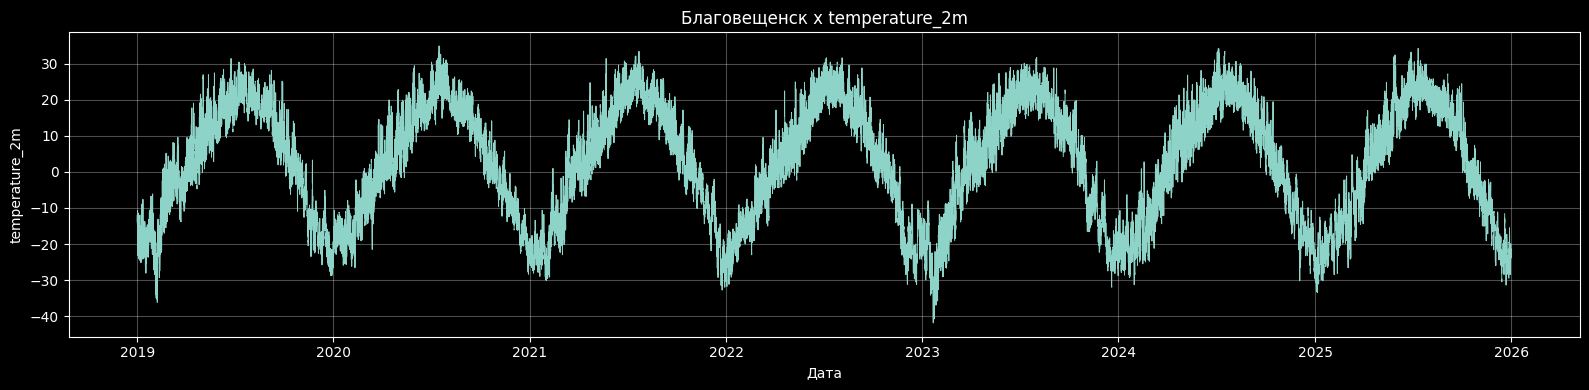

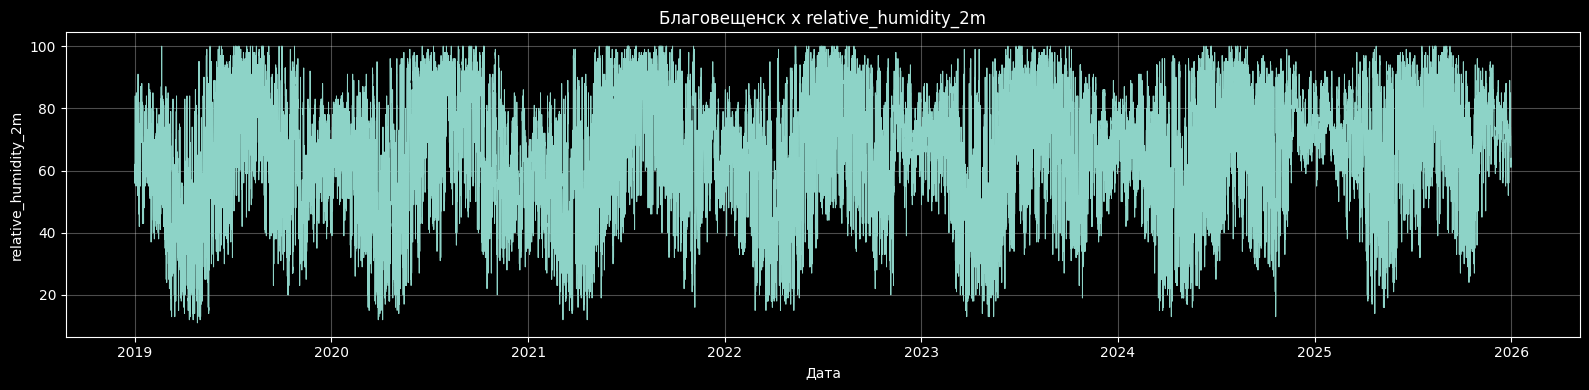

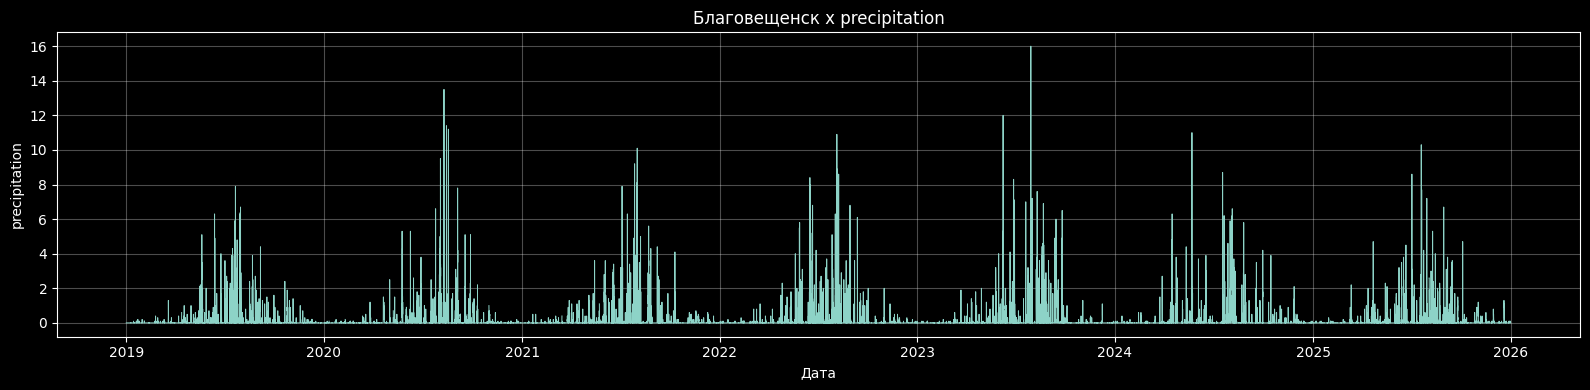

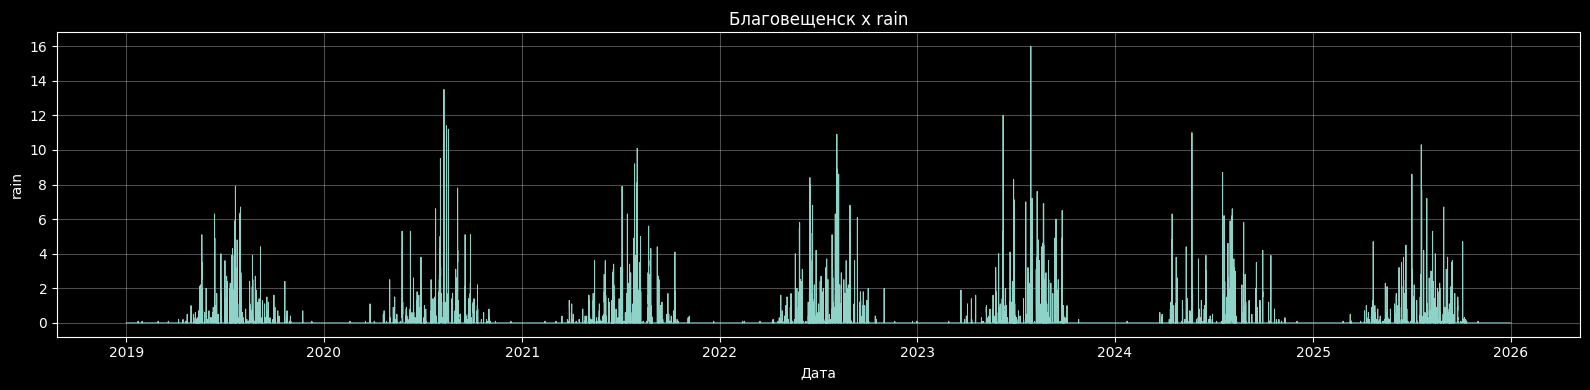

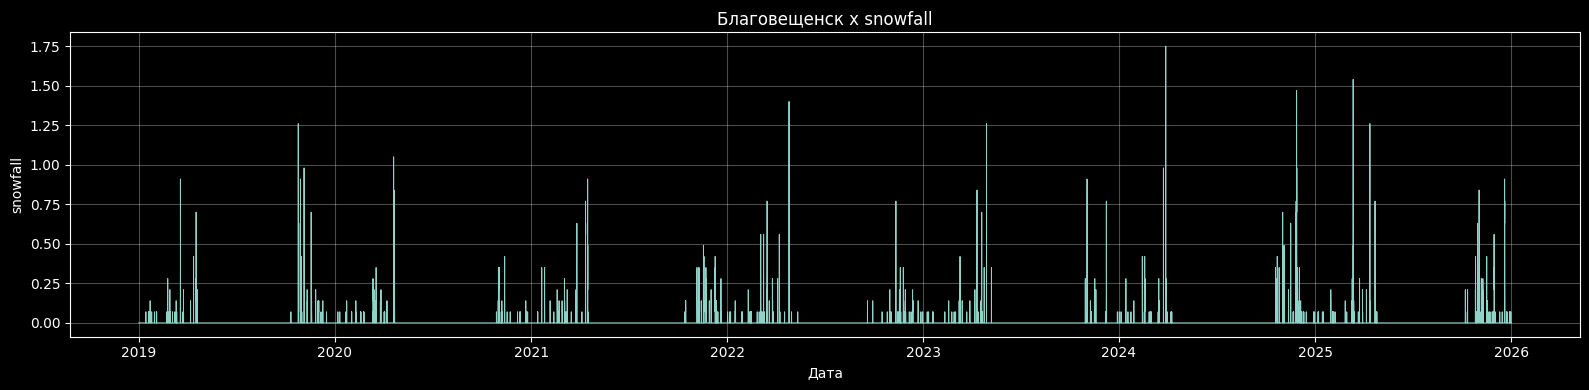

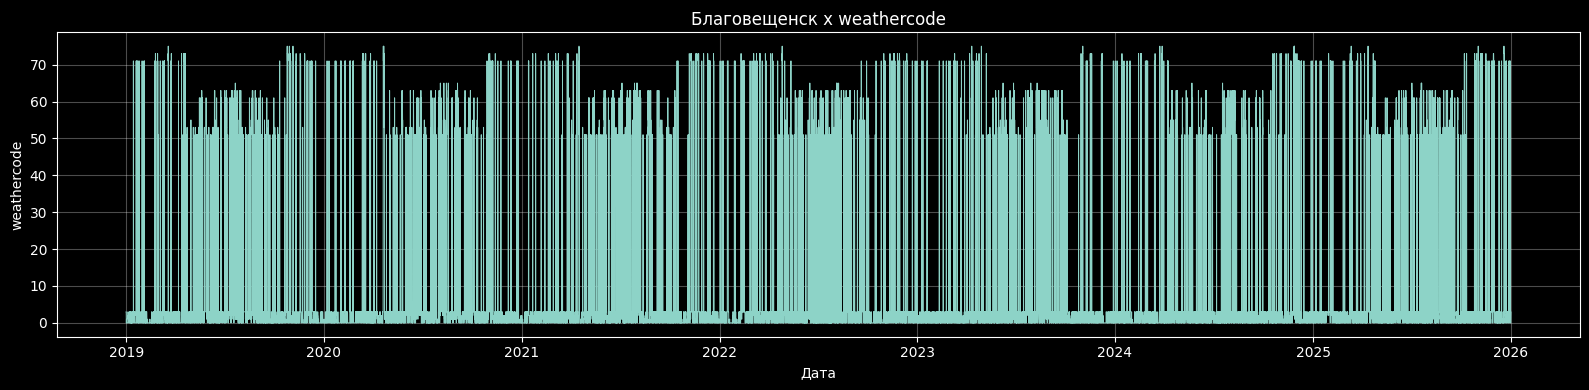

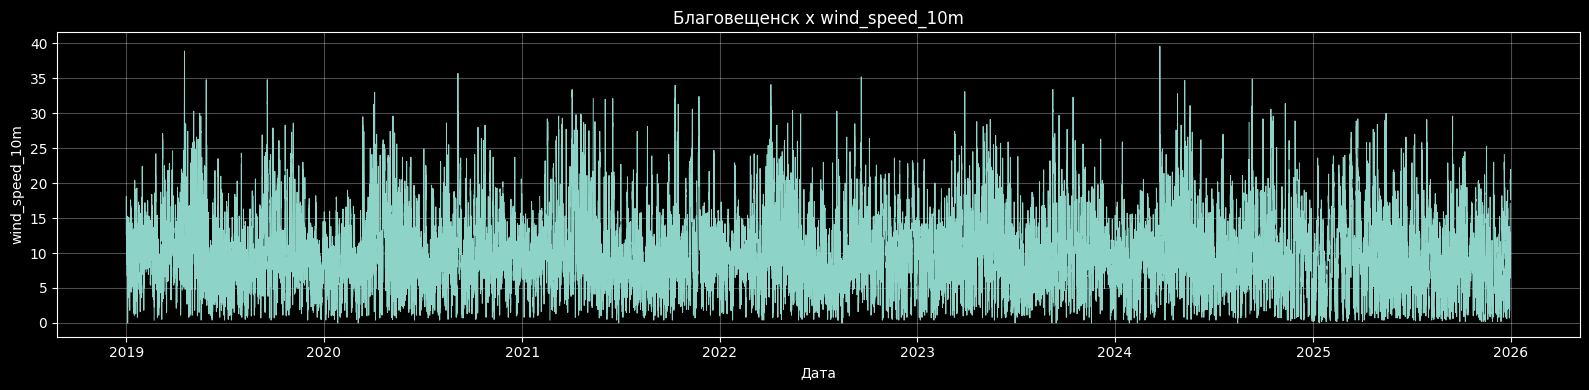

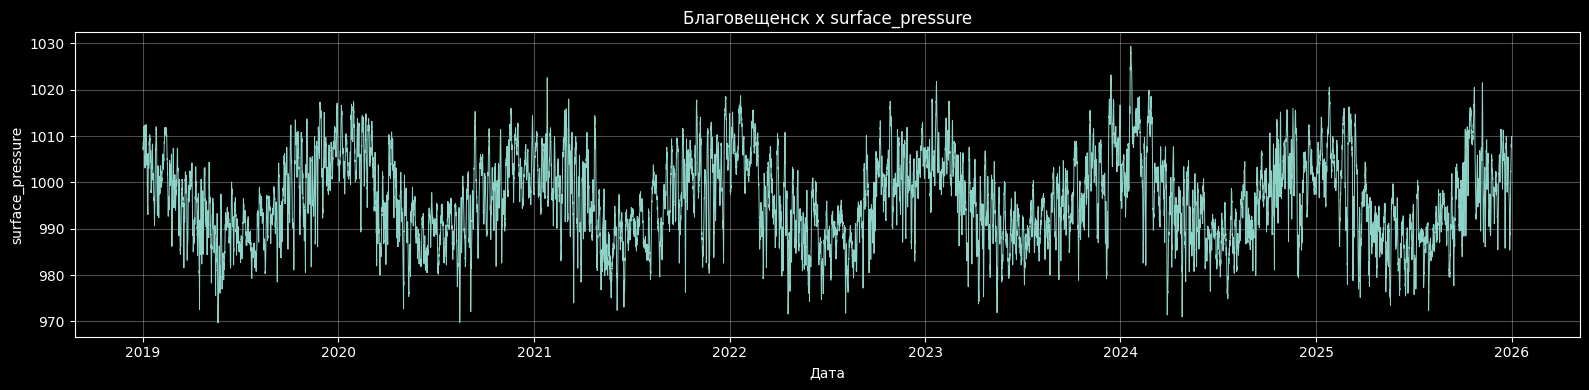

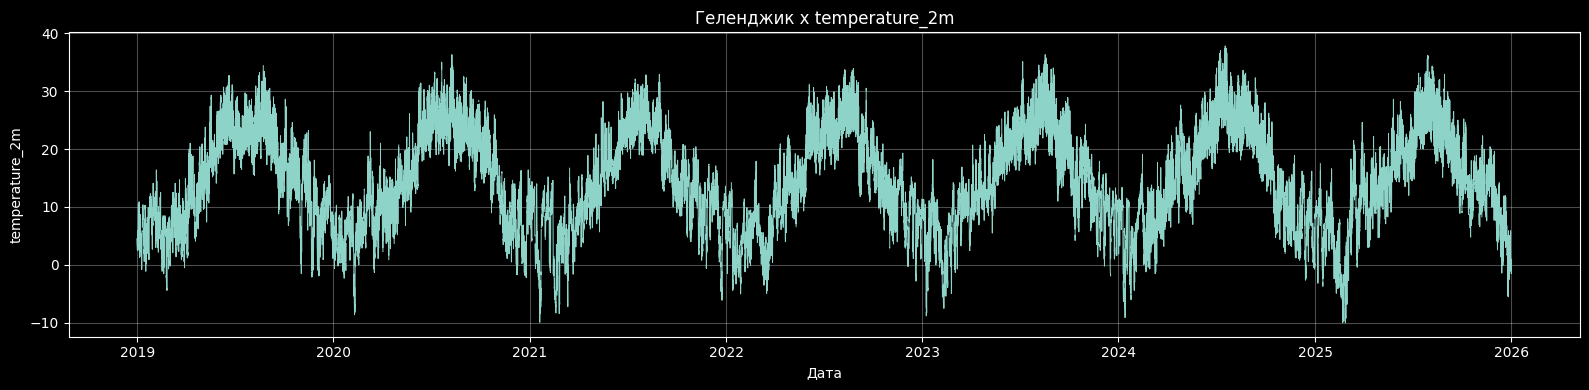

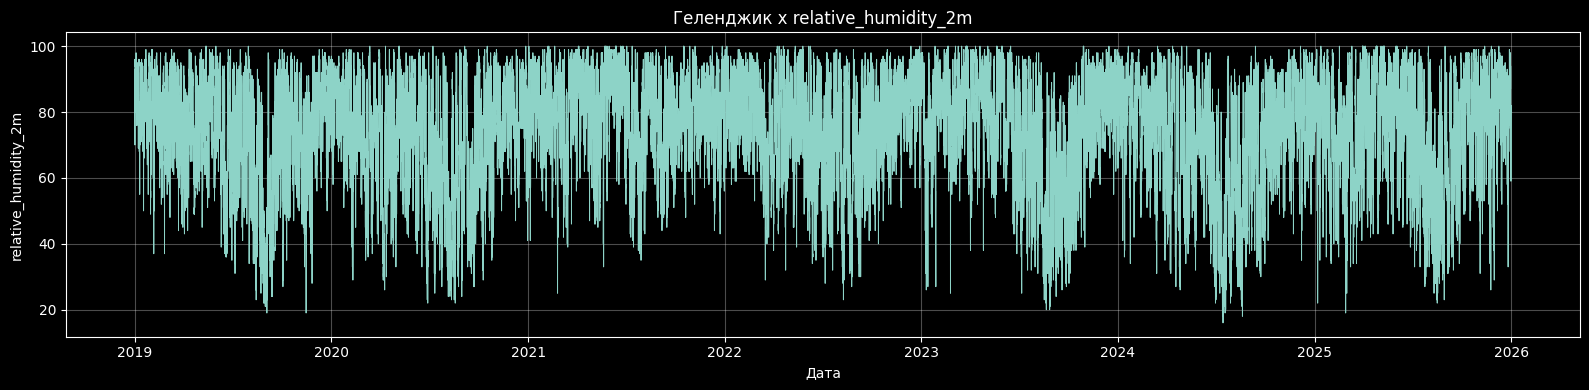

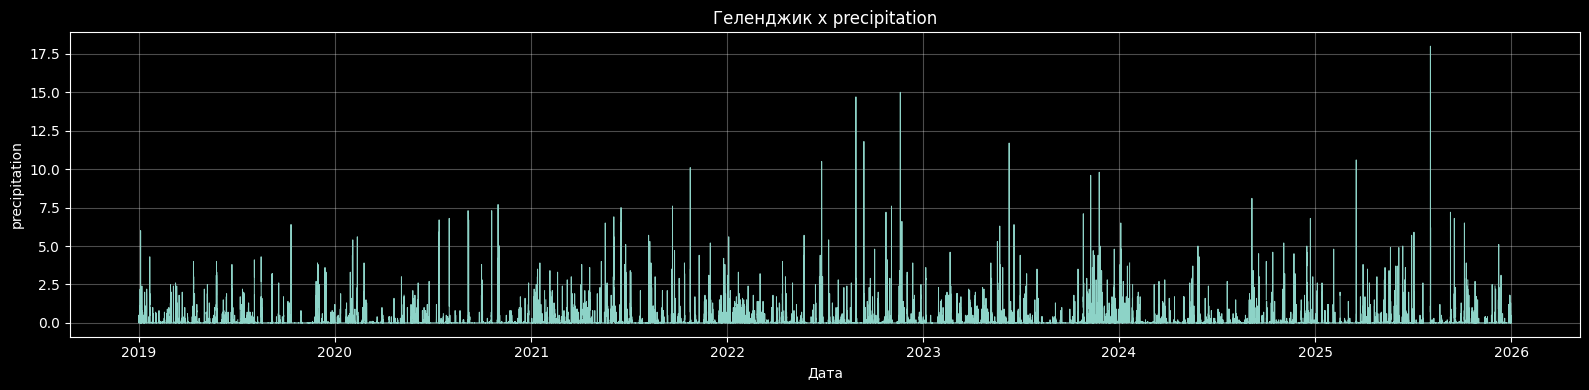

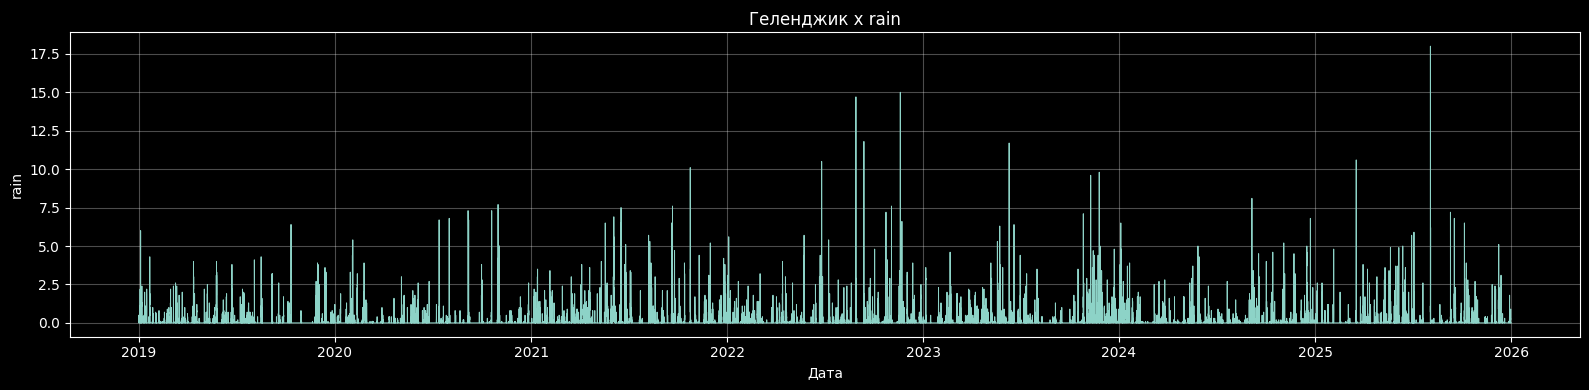

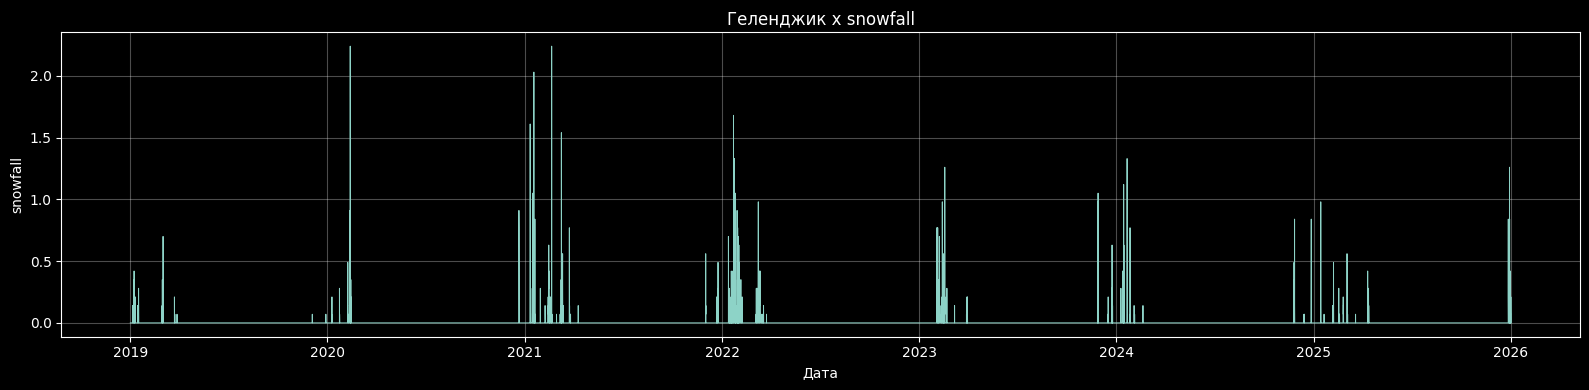

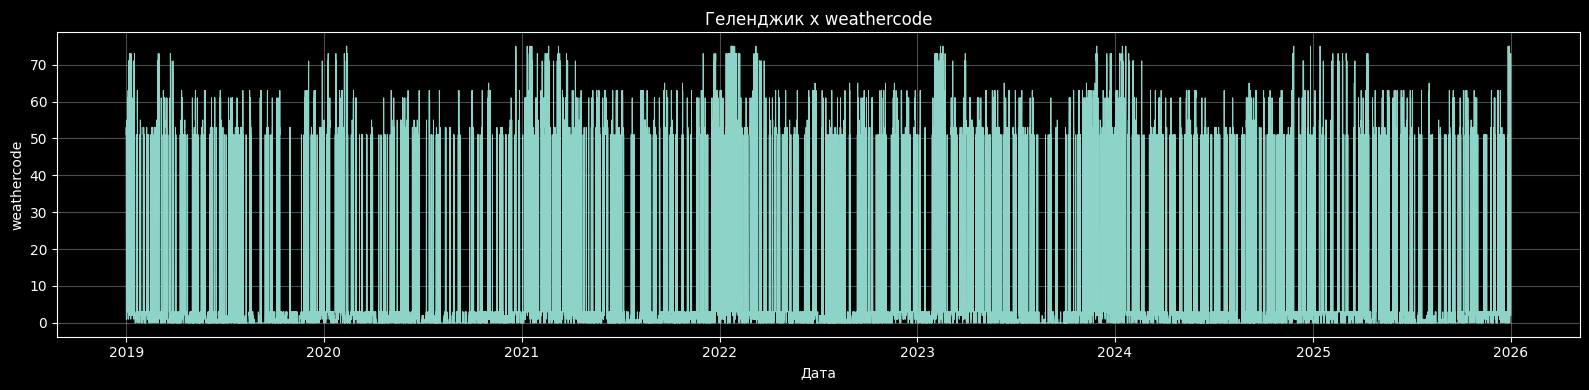

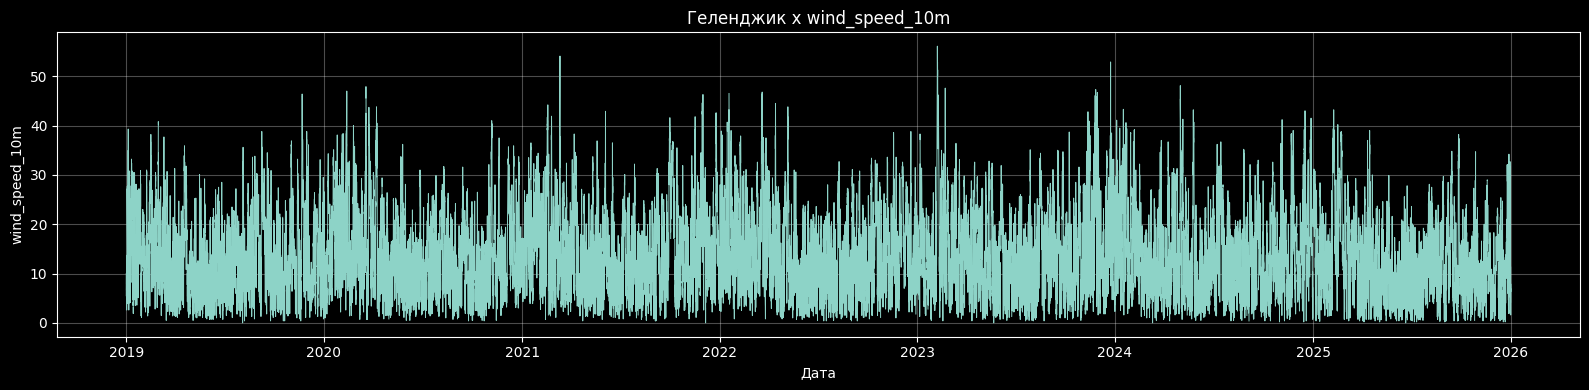

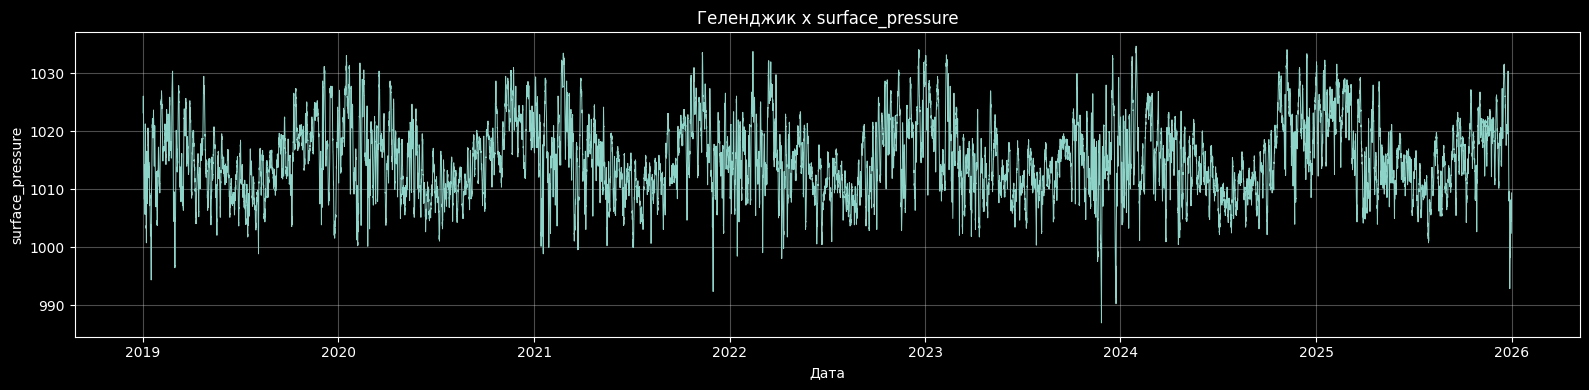

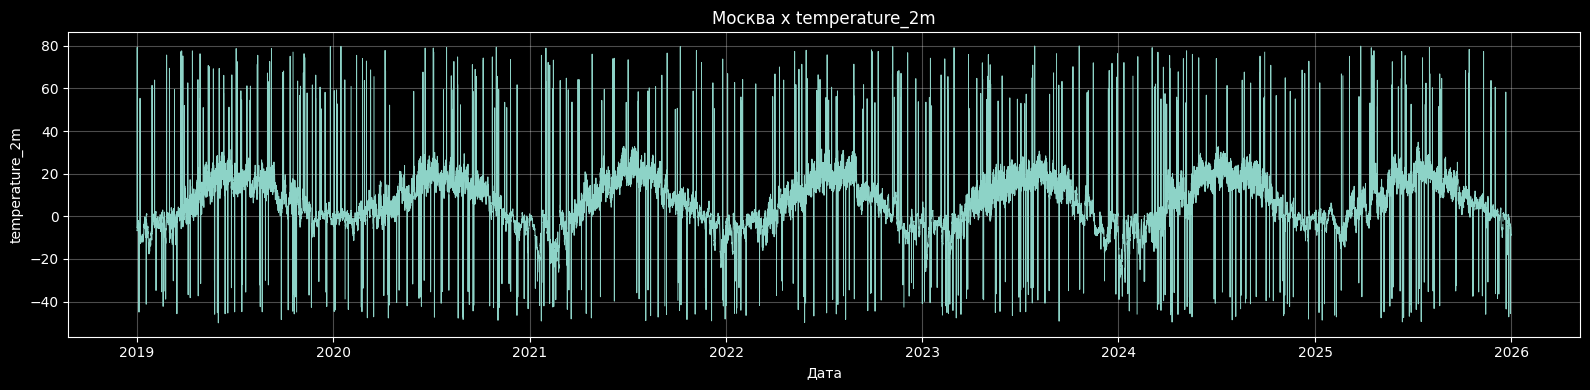

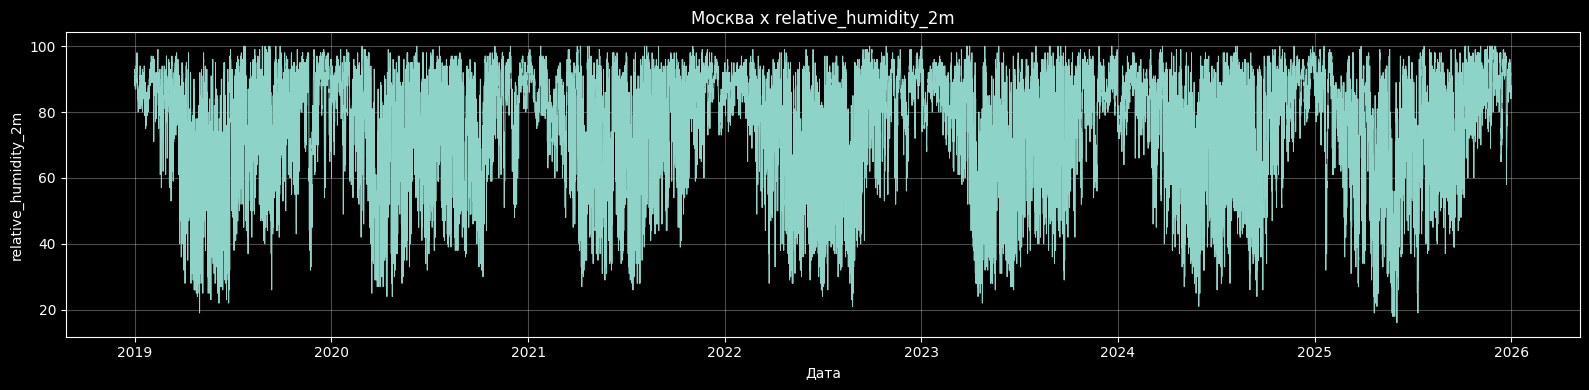

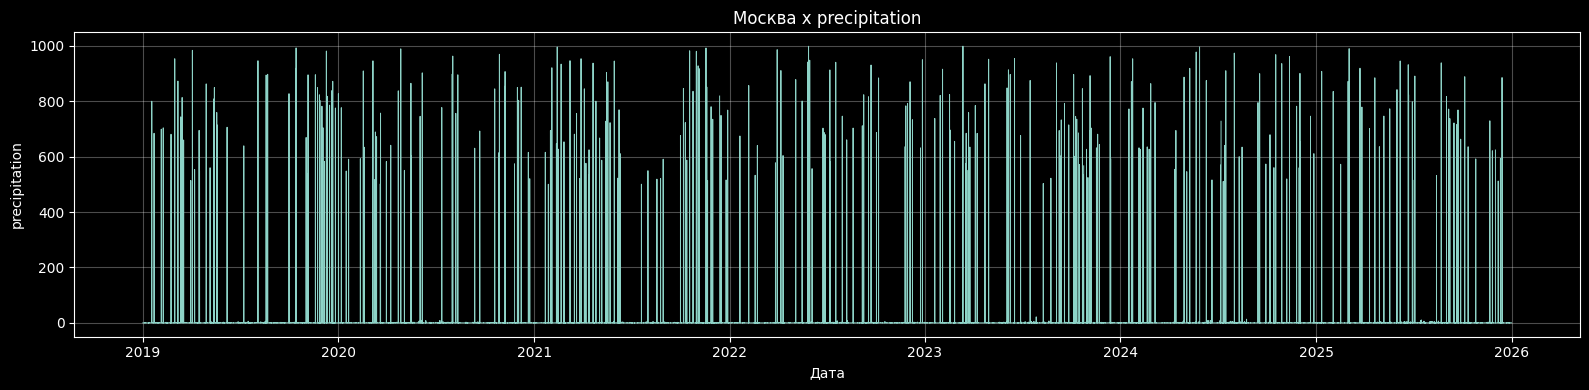

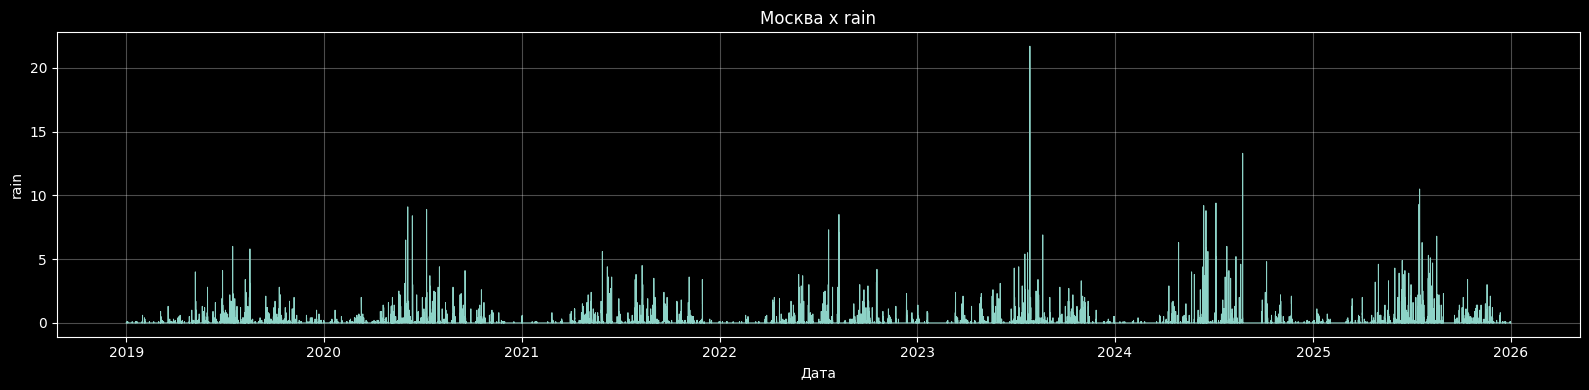

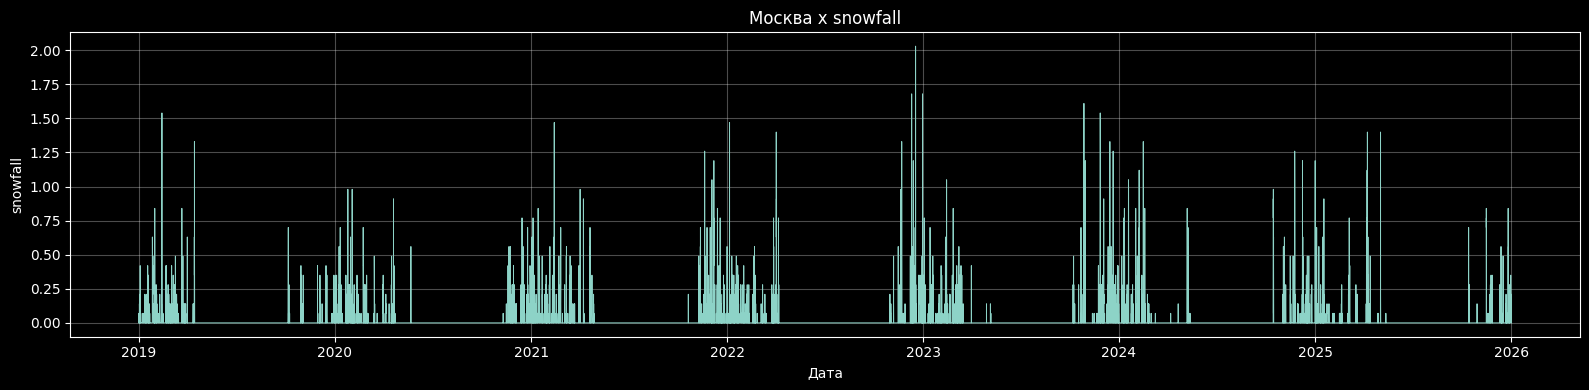

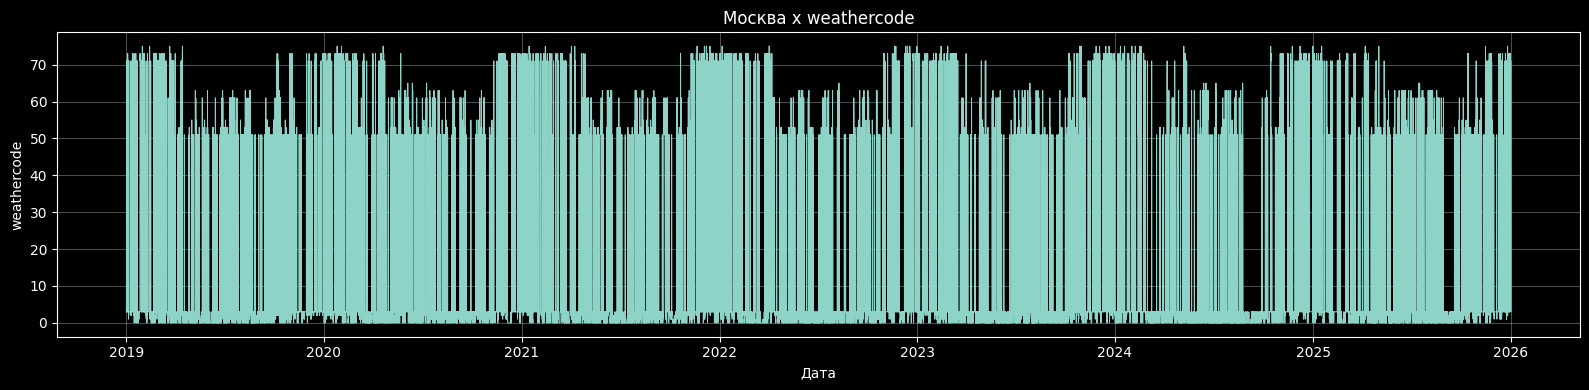

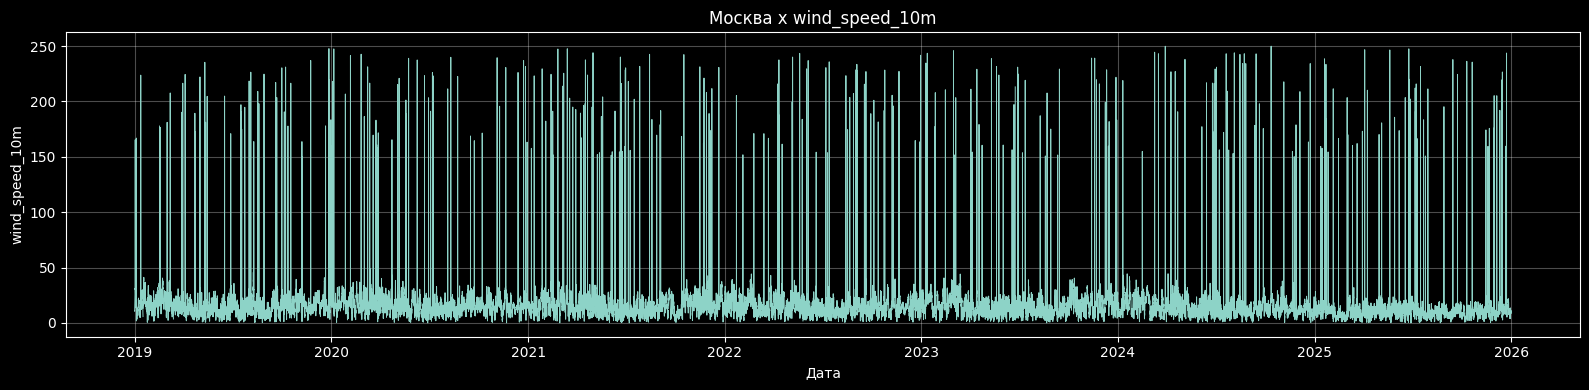

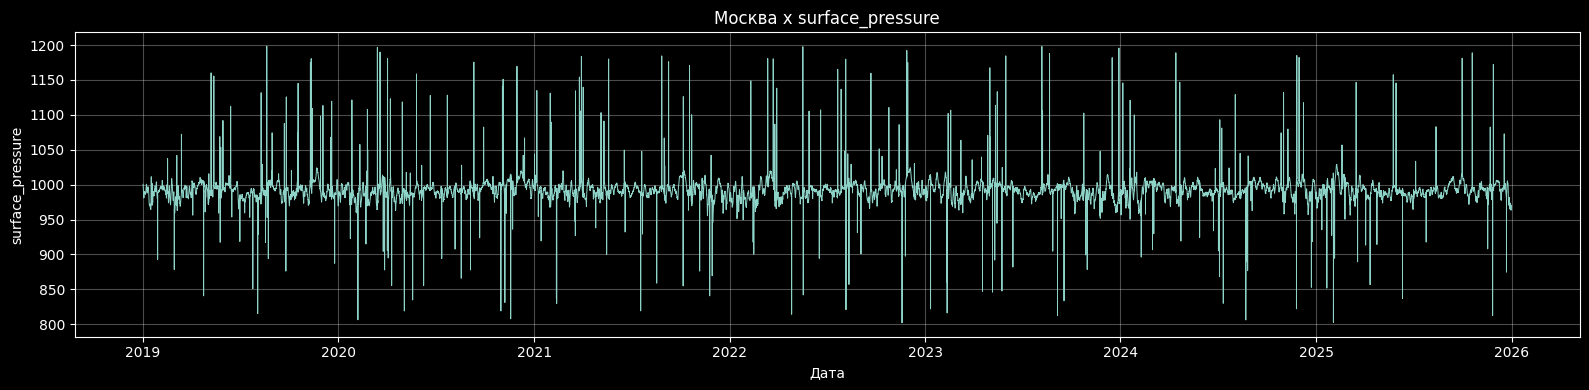

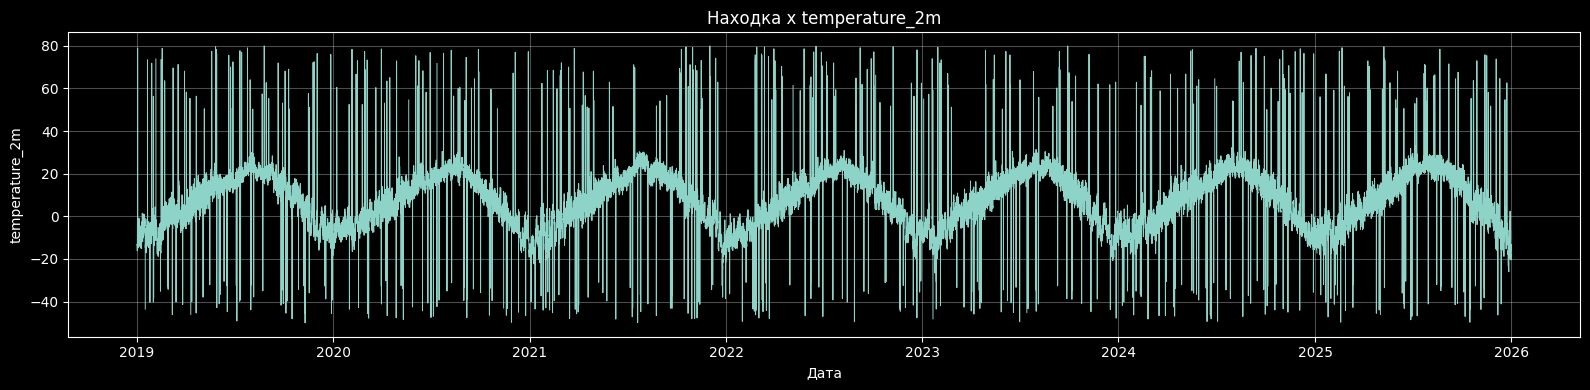

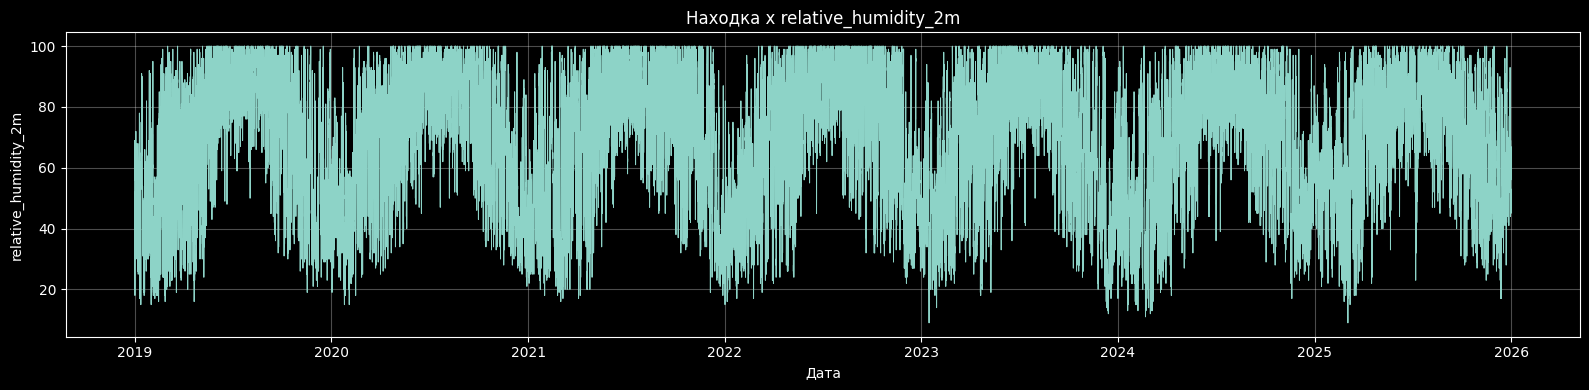

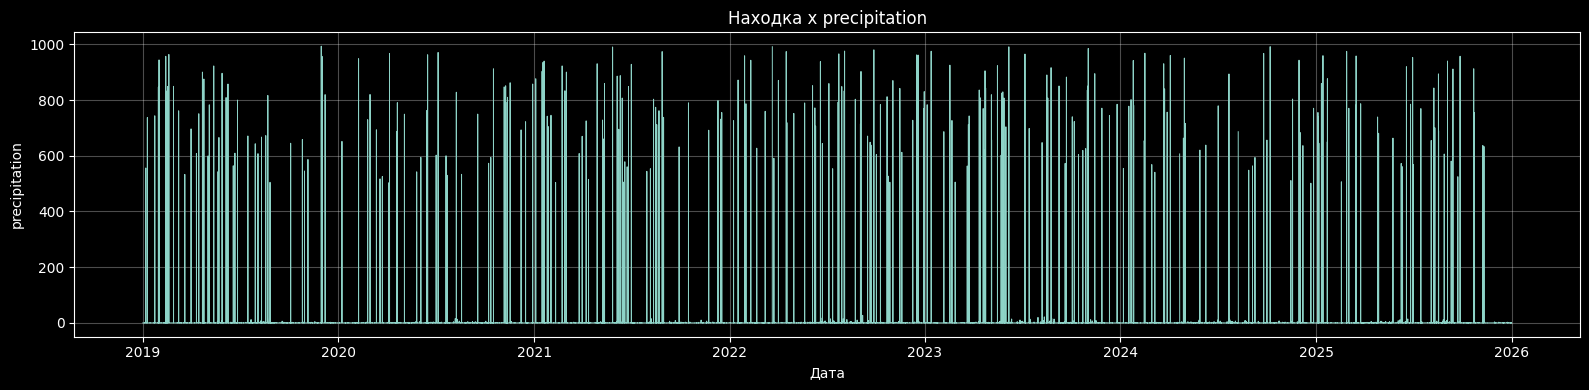

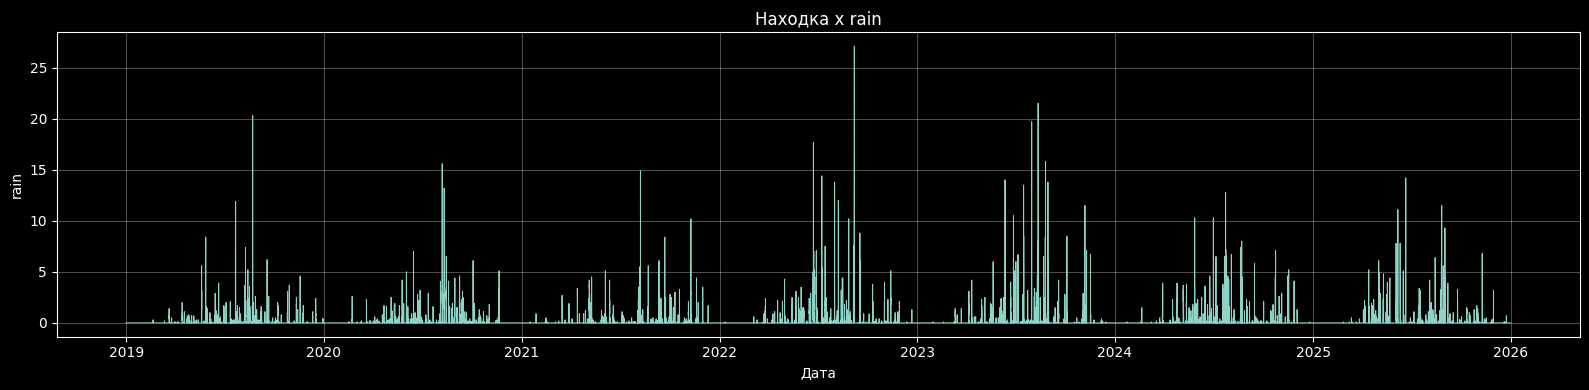

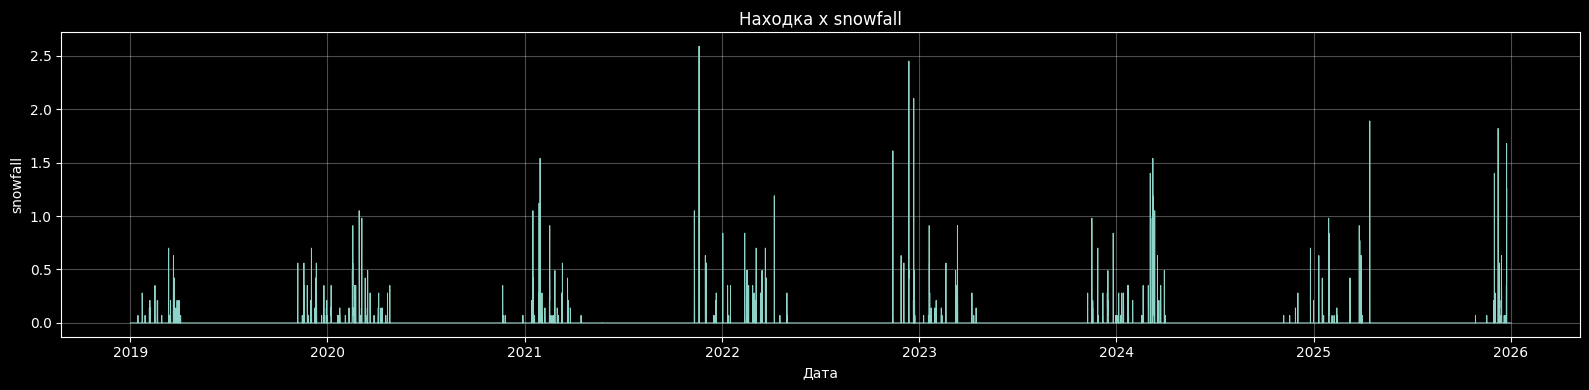

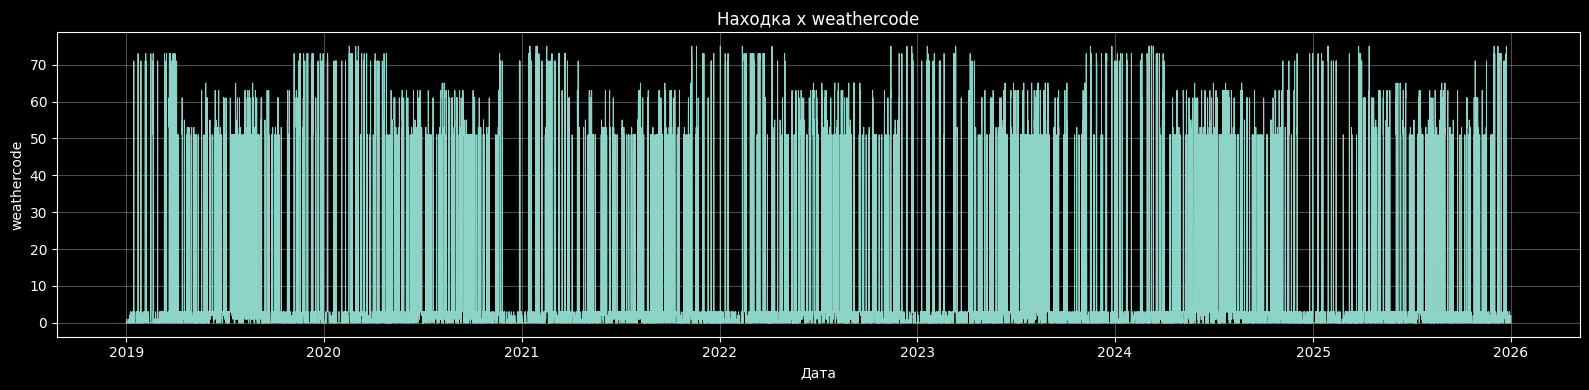

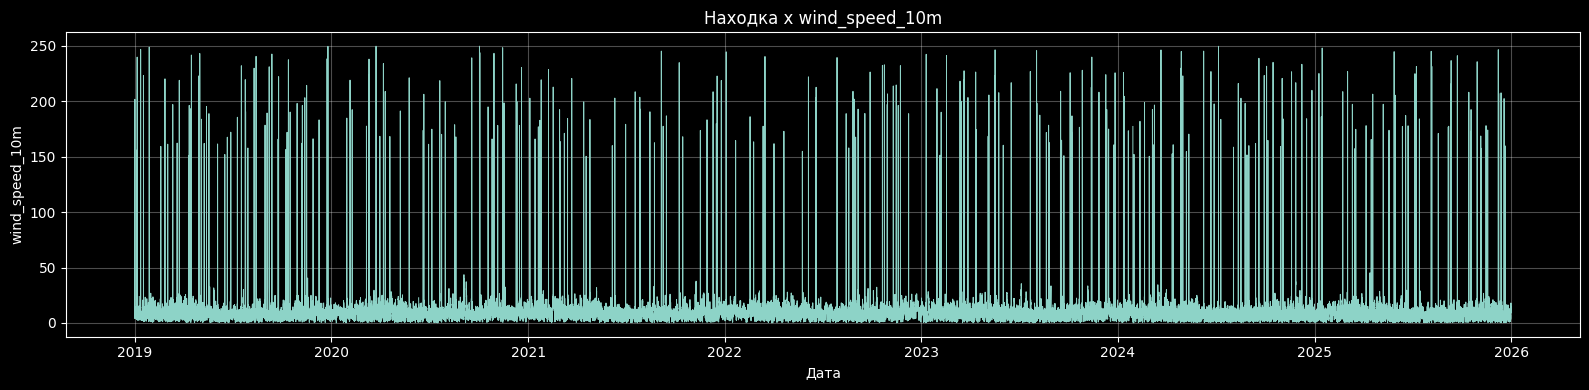

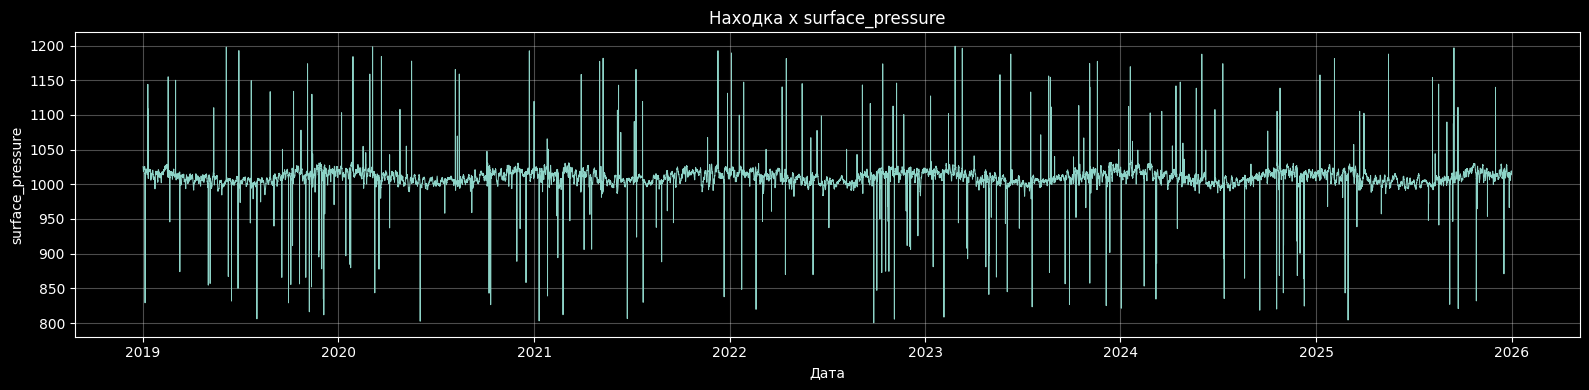

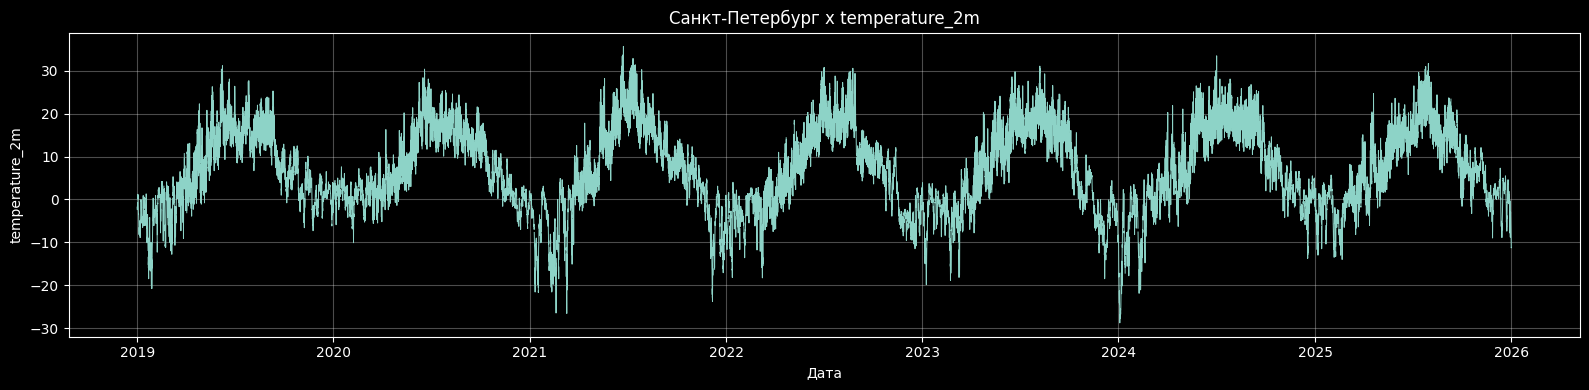

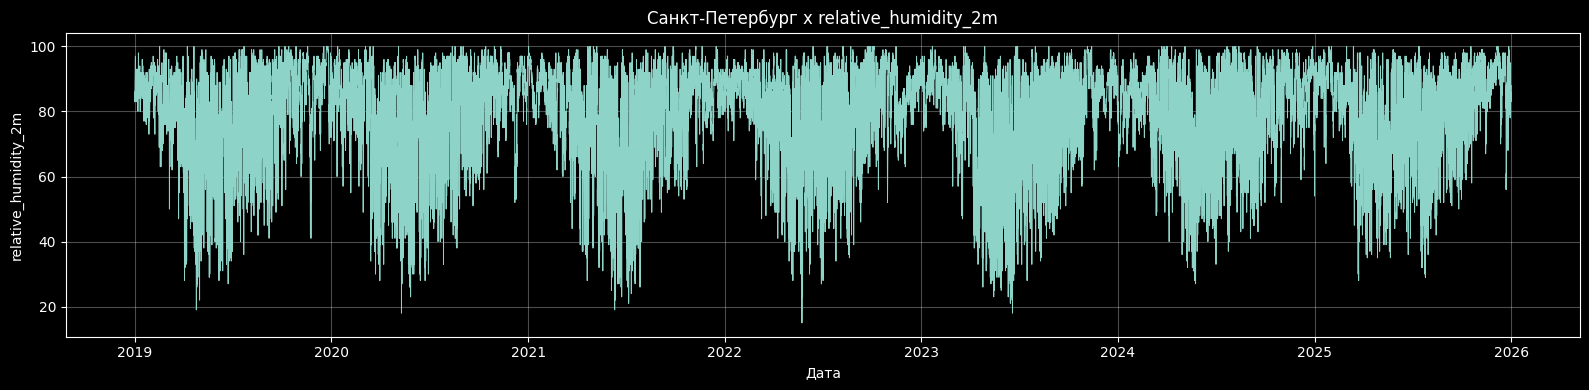

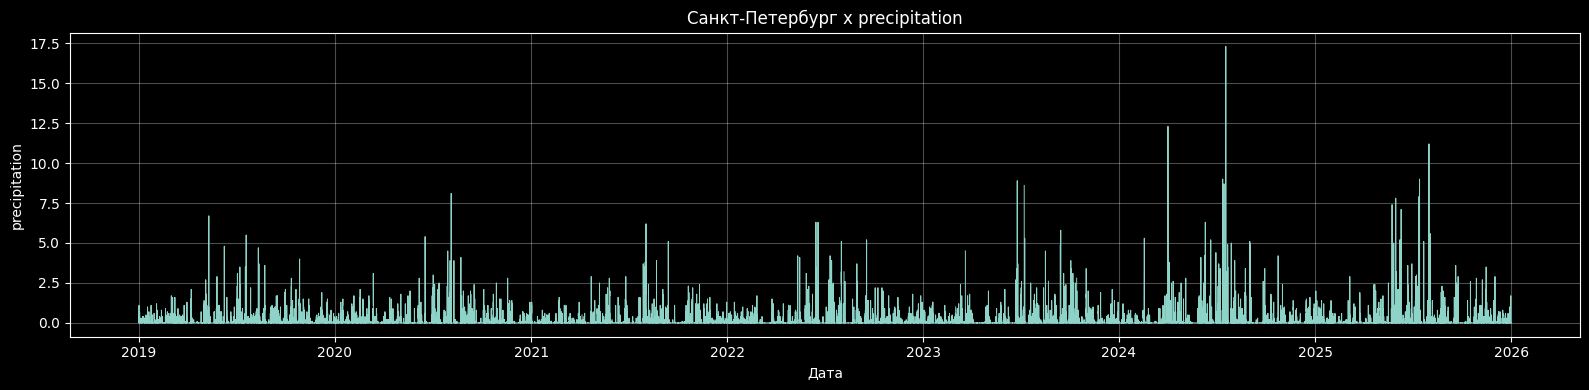

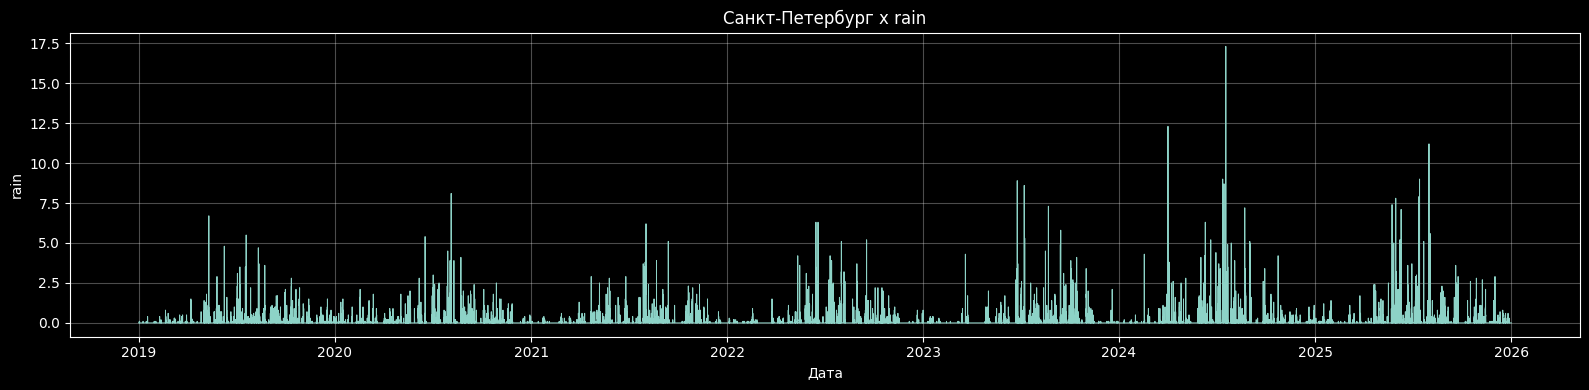

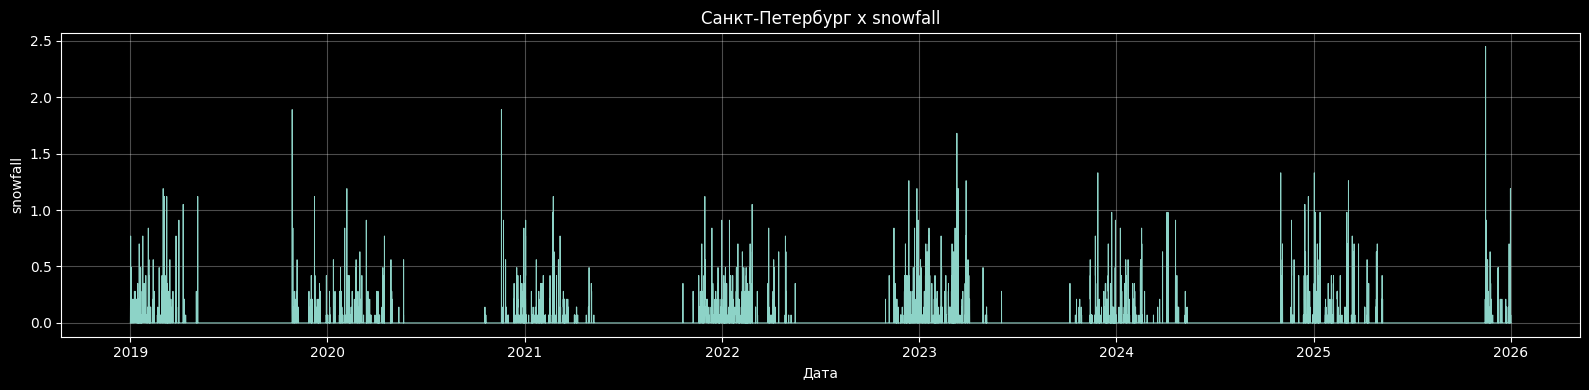

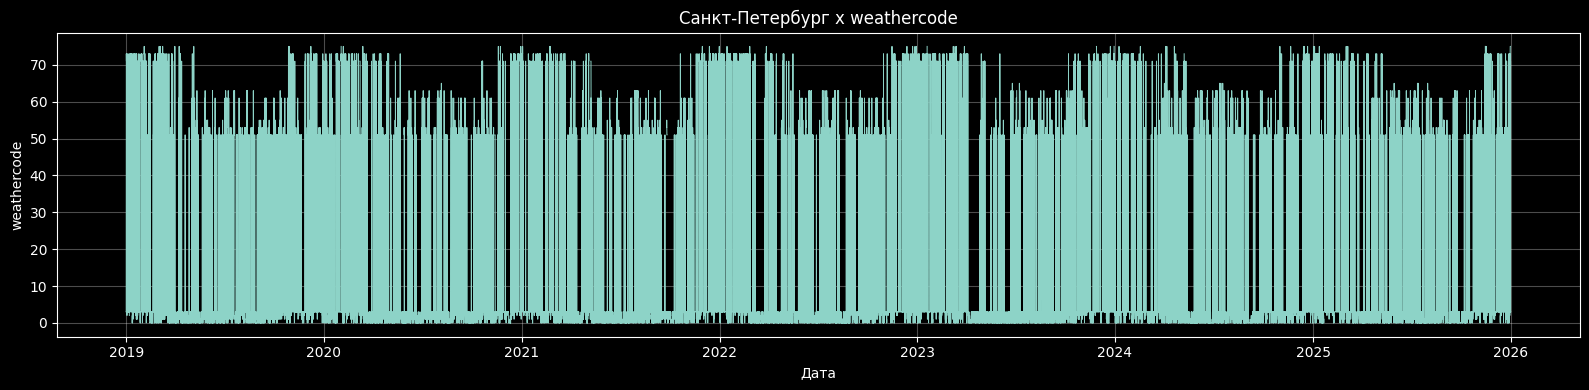

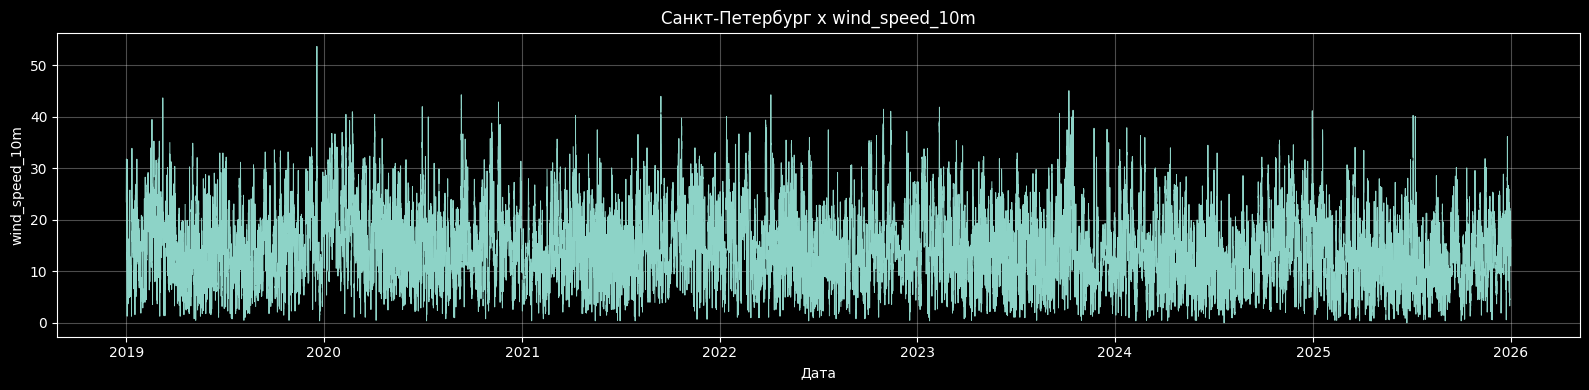

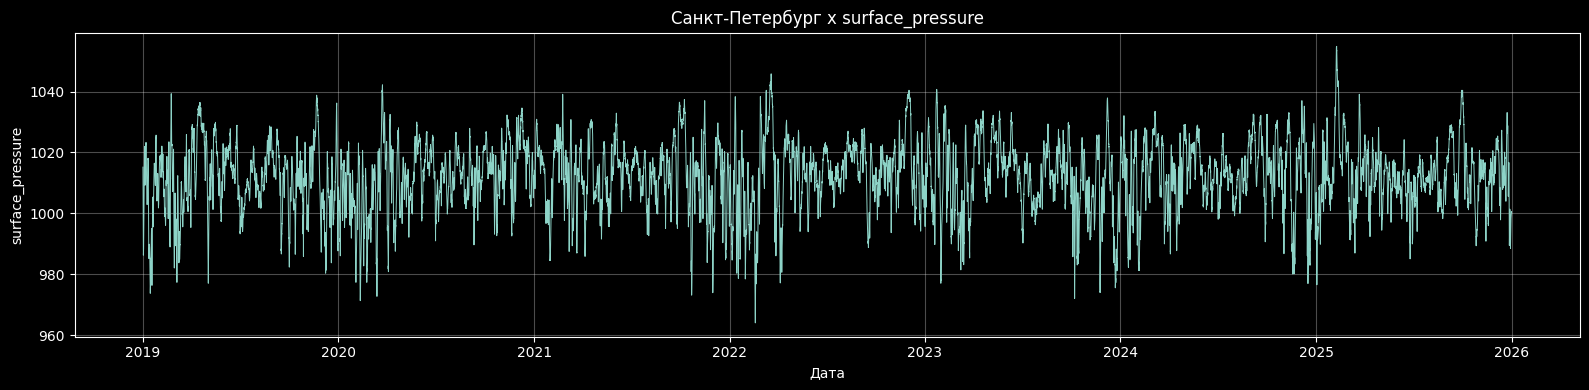

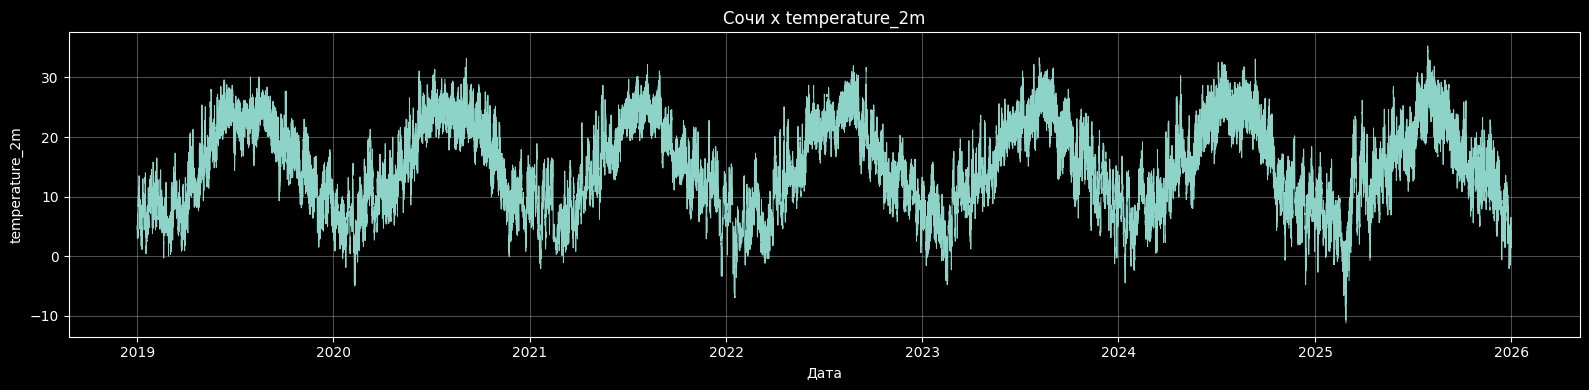

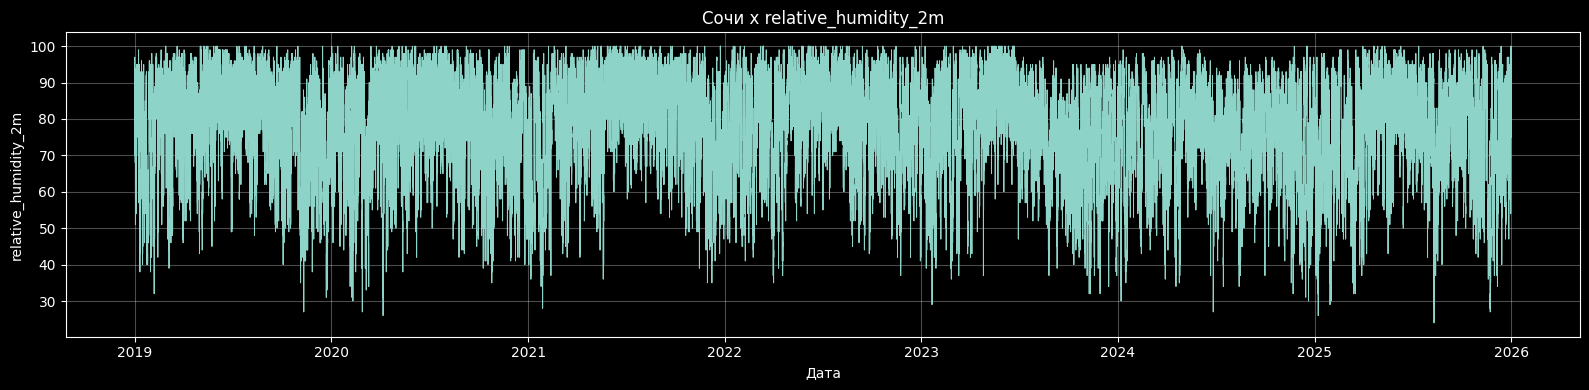

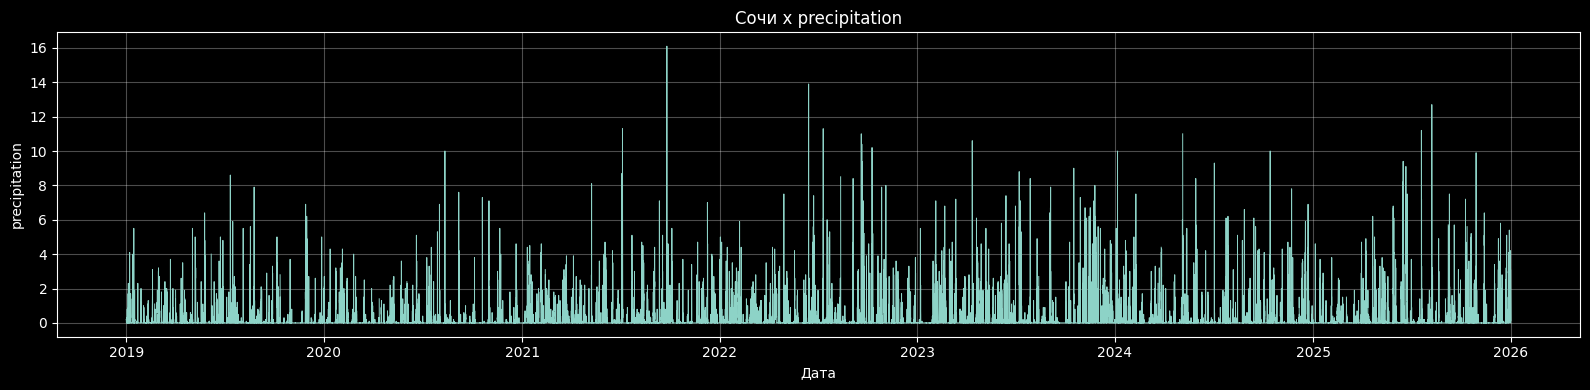

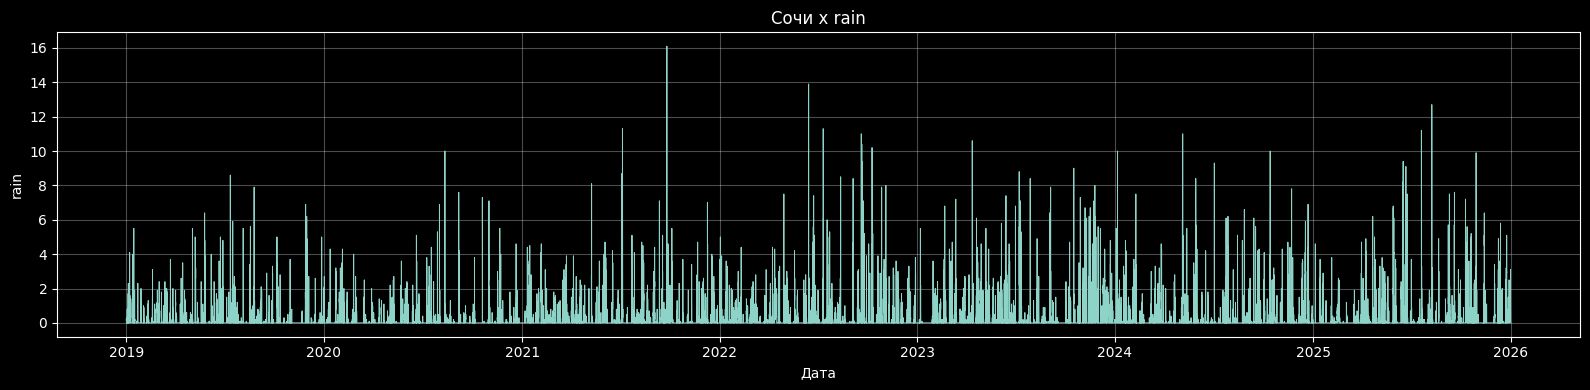

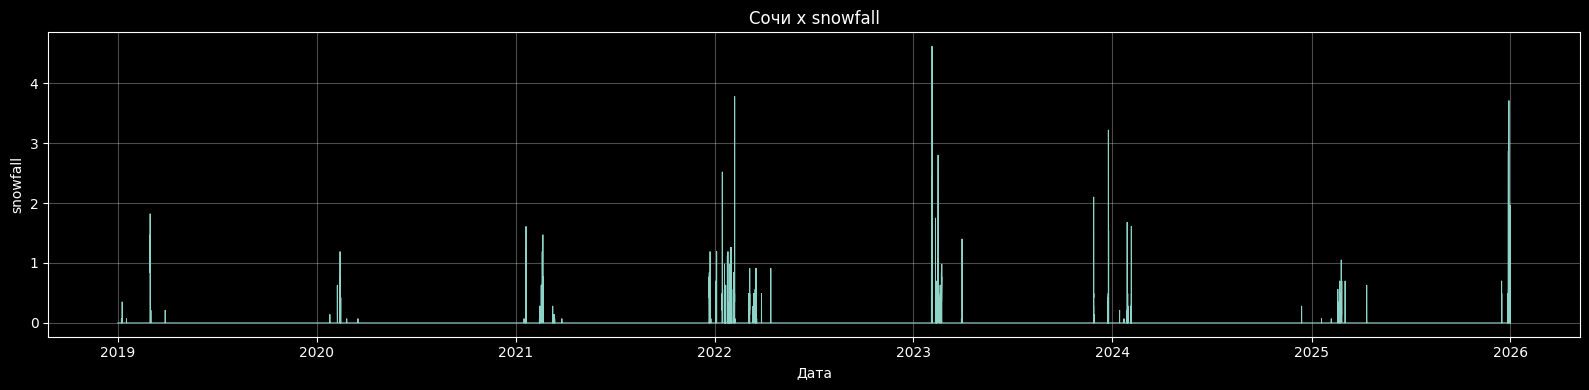

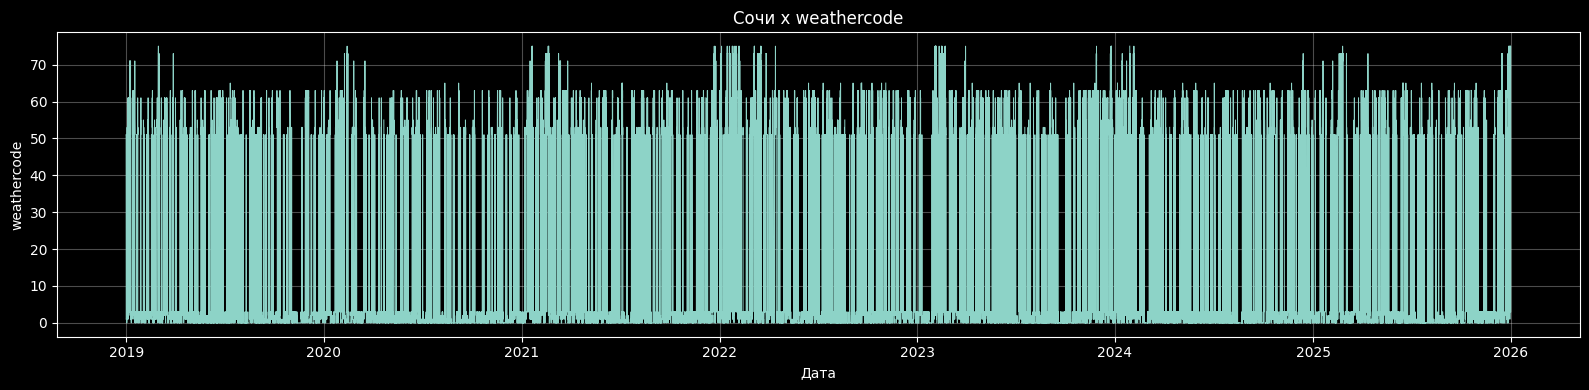

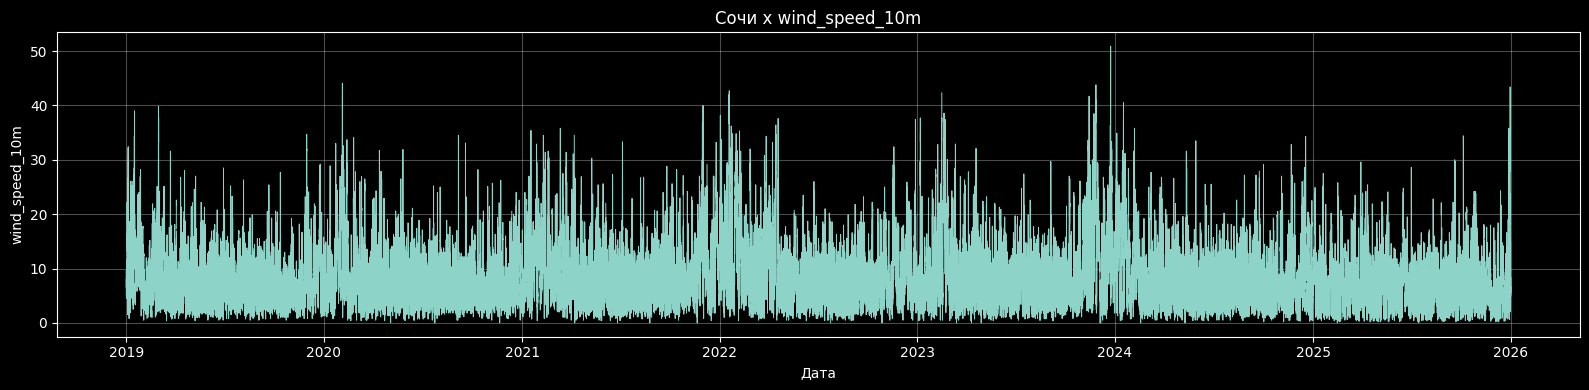

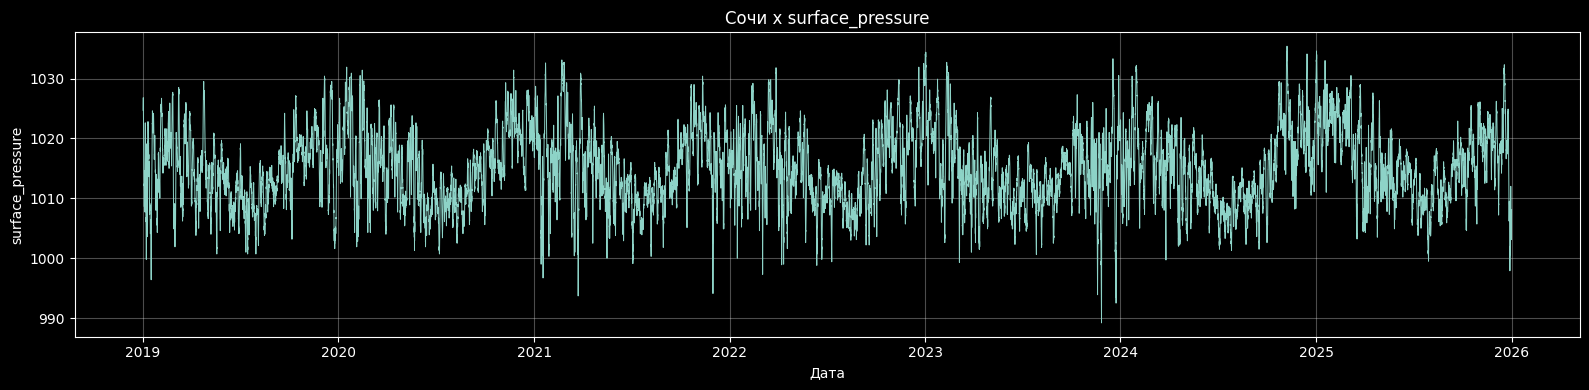

In [23]:
feature_cols = regular_df.columns.tolist()
cities = regular_df.index.get_level_values("city").unique()

for city in cities:
    city_df = regular_df.loc[city]

    for col in feature_cols:
        plt.figure(figsize=(16, 4))
        plt.plot(city_df.index, city_df[col], linewidth=0.7)

        plt.title(f"{city} x {col}")
        plt.xlabel("Дата")
        plt.ylabel(col)
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

In [19]:
# smooth_cols = ["temperature_2m", "relative_humidity_2m", "wind_speed_10m", "surface_pressure"]
#
# def fill_short_gaps(series, max_gap=3):
#     is_missing = series.isna()
#     gap_id = is_missing.ne(is_missing.shift()).cumsum()
#     gap_size = is_missing.groupby(gap_id).transform("sum")
#     short_gap = is_missing & (gap_size <= max_gap)
#     interpolated = series.interpolate(method="linear", limit_area="inside")
#     result = series.copy()
#     result[short_gap] = interpolated[short_gap]
#     return result
#
# filled_df = regular_df.sort_values(["city", "ds"]).reset_index(drop=True).copy()
#
# missing_before = filled_df[smooth_cols].isna().sum()
#
# for col in smooth_cols:
#     filled_df[col] = filled_df.groupby("city")[col].transform(lambda s: fill_short_gaps(s, max_gap=3))
#
# missing_after = filled_df[smooth_cols].isna().sum()
#
# display(pd.DataFrame({
#     "missing_before": missing_before,
#     "missing_after": missing_after,
#     "filled": missing_before - missing_after
# }))
